# Homicídios de mulheres no Brasil (1989~2023)
### Análise com taxas normalizadas por 100 mil habitantes

---

## 1. Introdução

Este notebook realiza uma análise das séries históricas de homicídios de mulheres no Brasil entre 1989 e 2023, **normalizada por 100 mil habitantes (total e feminino)**, a fim de controlar o efeito do crescimento populacional e permitir comparações temporais e espaciais mais justas.

A análise é organizada em torno de cinco **marcos institucionais**:

| Ano | Marco |
|-----|-------|
| 2003 | Lei nº 10.778 — Notificação compulsória da violência contra a mulher |
| 2006 | Lei Maria da Penha — Coibição da violência doméstica |
| 2010 | Red Pill — Movimento contracultural de contestação ao feminismo |
| 2015 | Lei do Feminicídio — Qualificação do homicídio por razão de gênero |
| 2020 | Pandemia de COVID-19 — Isolamento social e agravamento da violência doméstica |

**Fontes de dados:**
- Homicídios: Atlas da Violência / IPEA (dados municipais)
- População: IBGE — Censos, estimativas intercensitárias e projeções (consolidado)
- Codificação geográfica: IBGE — tabela de municípios por UF

## 2. Configuração e importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

PASTA = r'G:\Meu Drive\TCC\Rodrigo_\Bases\final'

MARCOS = [
    {'ano': 2003, 'label': 'Lei 10.778\n(2003)',      'cor': '#1F6FAF'},
    {'ano': 2006, 'label': 'Lei Maria da Penha\n(2006)', 'cor': '#C0392B'},
    {'ano': 2010, 'label': 'Red Pill\n(2010)',         'cor': '#27AE60'},
    {'ano': 2015, 'label': 'Lei Feminicídio\n(2015)',  'cor': '#D68910'},
    {'ano': 2020, 'label': 'Pandemia\n(2020)',         'cor': '#7D3C98'},
]

MAPA_REGIAO = {
    'Acre': 'Norte', 'Amapá': 'Norte', 'Amazonas': 'Norte', 'Pará': 'Norte',
    'Rondônia': 'Norte', 'Roraima': 'Norte', 'Tocantins': 'Norte',
    'Alagoas': 'Nordeste', 'Bahia': 'Nordeste', 'Ceará': 'Nordeste',
    'Maranhão': 'Nordeste', 'Paraíba': 'Nordeste', 'Pernambuco': 'Nordeste',
    'Piauí': 'Nordeste', 'Rio Grande do Norte': 'Nordeste', 'Sergipe': 'Nordeste',
    'Espírito Santo': 'Sudeste', 'Minas Gerais': 'Sudeste',
    'Rio de Janeiro': 'Sudeste', 'São Paulo': 'Sudeste',
    'Paraná': 'Sul', 'Rio Grande do Sul': 'Sul', 'Santa Catarina': 'Sul',
    'Distrito Federal': 'Centro-Oeste', 'Goiás': 'Centro-Oeste',
    'Mato Grosso': 'Centro-Oeste', 'Mato Grosso do Sul': 'Centro-Oeste',
}

CORES_REGIAO = {
    'Norte': '#1F6FAF',
    'Nordeste': '#C0392B',
    'Sudeste': '#27AE60',
    'Sul': '#D68910',
    'Centro-Oeste': '#7D3C98',
}

## 3. Carregamento e preparação dos dados

### 3.1 Carga dos arquivos brutos

In [2]:
import os

def ler_csv_homicidio(nome_arquivo, serie_nome):
    caminho = os.path.join(PASTA, nome_arquivo)
    df = pd.read_csv(caminho, sep=';', encoding='latin1')
    df.columns = ['cod', 'nome', 'periodo', 'valor']
    df['serie'] = serie_nome
    return df

df_hom_total     = ler_csv_homicidio('homicidios.csv',                           'homicidios_total')
df_hom_mulheres  = ler_csv_homicidio('homicidios-mulheres.csv',                  'homicidios_mulheres')
df_hom_negras    = ler_csv_homicidio('homicidios-mulheres-negras.csv',           'homicidios_mulheres_negras')
df_hom_nao_neg   = ler_csv_homicidio('homicidios-mulheres-nao-negras.csv',      'homicidios_mulheres_nao_negras')
df_hom_jovens    = ler_csv_homicidio('homicidios-de-jovens-mulheres.csv',        'homicidios_jovens_mulheres')
df_hom_armas     = ler_csv_homicidio('homicidios-de-mulheres-por-armas-de-fogo.csv', 'homicidios_mulheres_armas_fogo')

df_ibge = pd.read_csv(os.path.join(PASTA, 'ibge_codigos_municipios.csv'), encoding='latin1', sep=';')
df_ibge = df_ibge[['UF', 'Nome_UF', 'Código Município Completo']].copy()
df_ibge.columns = ['UF_cod', 'UF_nome', 'cod']
df_ibge = df_ibge.drop_duplicates(subset='cod')

df_pop = pd.read_excel(os.path.join(PASTA, 'populacao_consolidada.xlsx'))

print('Homicídios total (linhas):', len(df_hom_total))
print('Homicídios mulheres (linhas):', len(df_hom_mulheres))
print('População (linhas):', len(df_pop))
print('Período disponível:', df_hom_mulheres['periodo'].min(), '–', df_hom_mulheres['periodo'].max())

Homicídios total (linhas): 191442
Homicídios mulheres (linhas): 194644
População (linhas): 999
Período disponível: 1989 – 2023


### 3.2 Agregação municipal → UF

Os dados de homicídios estão no nível municipal (código IBGE de 7 dígitos). O join com a tabela de municípios permite identificar a UF de cada registro, possibilitando a agregação estadual.

In [3]:
df_todas = pd.concat([
    df_hom_total, df_hom_mulheres, df_hom_negras,
    df_hom_nao_neg, df_hom_jovens, df_hom_armas
], ignore_index=True)

df_todas = df_todas.merge(df_ibge, on='cod', how='left')

sem_uf = df_todas['UF_nome'].isna().sum()
print(f'Registros sem UF identificada: {sem_uf} ({sem_uf/len(df_todas)*100:.1f}%)')

df_todas = df_todas.dropna(subset=['UF_nome'])

df_uf = (
    df_todas
    .groupby(['UF_nome', 'periodo', 'serie'], as_index=False)
    .agg(valor_uf=('valor', 'sum'))
)

df_uf.columns = ['Estado', 'Ano', 'serie', 'valor_uf']
df_uf['Regiao'] = df_uf['Estado'].map(MAPA_REGIAO)

print(df_uf.head())

Registros sem UF identificada: 0 (0.0%)
  Estado   Ano                           serie  valor_uf Regiao
0   Acre  1989      homicidios_jovens_mulheres         4  Norte
1   Acre  1989             homicidios_mulheres         6  Norte
2   Acre  1989  homicidios_mulheres_armas_fogo         3  Norte
3   Acre  1989                homicidios_total        95  Norte
4   Acre  1990      homicidios_jovens_mulheres         4  Norte


### 3.3 Join com a população e cálculo das taxas normalizadas

Duas taxas são calculadas:
- **Taxa por 100 mil habitantes (total):** divide o valor pelo total da população do estado no ano, multiplicado por 100.000. Permite comparação com a violência geral.
- **Taxa por 100 mil mulheres:** divide pelo número de mulheres (coluna `Feminino`), também multiplicado por 100.000. Mais precisa para análise específica da violência contra a mulher, pois controla a proporção feminina na população.

In [4]:
df_uf = df_uf.merge(df_pop, on=['Estado', 'Ano'], how='left')

pop_faltante = df_uf[df_uf['Total'].isna()]['Ano'].unique()
if len(pop_faltante) > 0:
    print('Anos sem população:', sorted(pop_faltante))

df_uf['taxa_100k_total']   = df_uf['valor_uf'] / df_uf['Total']    * 100_000
df_uf['taxa_100k_fem']     = df_uf['valor_uf'] / df_uf['Feminino'] * 100_000

print('Colunas finais:', df_uf.columns.tolist())
print(df_uf[df_uf['serie'] == 'homicidios_mulheres'].head(6).to_string())

Colunas finais: ['Estado', 'Ano', 'serie', 'valor_uf', 'Regiao', 'Feminino', 'Masculino', 'Total', 'taxa_100k_total', 'taxa_100k_fem']
   Estado   Ano                serie  valor_uf Regiao  Feminino  Masculino   Total  taxa_100k_total  taxa_100k_fem
1    Acre  1989  homicidios_mulheres         6  Norte    195135     201200  396335         1.513871       3.074794
5    Acre  1990  homicidios_mulheres         6  Norte    200249     206026  406275         1.476832       2.996270
9    Acre  1991  homicidios_mulheres         9  Norte    206144     211574  417718         2.154564       4.365880
13   Acre  1992  homicidios_mulheres        13  Norte    212092     217591  429683         3.025486       6.129416
17   Acre  1993  homicidios_mulheres        12  Norte    215841     221658  437499         2.742863       5.559648
21   Acre  1994  homicidios_mulheres        11  Norte    220267     226206  446473         2.463755       4.993939


### 3.4 Série Brasil — agregação nacional

In [5]:
df_brasil = (
    df_uf
    .groupby(['Ano', 'serie'], as_index=False)
    .agg(
        valor_brasil=('valor_uf', 'sum'),
        pop_total=('Total', 'sum'),
        pop_fem=('Feminino', 'sum')
    )
)

df_brasil['taxa_100k_total'] = df_brasil['valor_brasil'] / df_brasil['pop_total'] * 100_000
df_brasil['taxa_100k_fem']   = df_brasil['valor_brasil'] / df_brasil['pop_fem']   * 100_000

df_brasil_mul = df_brasil[df_brasil['serie'] == 'homicidios_mulheres'].copy()
print('Série nacional homicídios mulheres (amostra):')
print(df_brasil_mul[['Ano','valor_brasil','taxa_100k_total','taxa_100k_fem']].head(10).to_string())

Série nacional homicídios mulheres (amostra):
     Ano  valor_brasil  taxa_100k_total  taxa_100k_fem
1   1989          2240         1.580638       3.124985
5   1990          2440         1.693377       3.346271
9   1991          2574         1.753102       3.462453
13  1992          2298         1.545558       3.051321
17  1993          2491         1.643611       3.245984
21  1994          2744         1.784989       3.525409
25  1995          3206         2.057472       4.063766
29  1996          3551         2.260773       4.459526
33  1997          3459         2.166800       4.274457
37  1998          3375         2.086035       4.115240


---

## 4. Visualizações

### 4.1 Série histórica nacional: bruta vs. normalizada

Comparação entre a contagem absoluta de homicídios de mulheres e as duas taxas normalizadas. O objetivo é evidenciar como o crescimento populacional pode mascarar tendências reais.

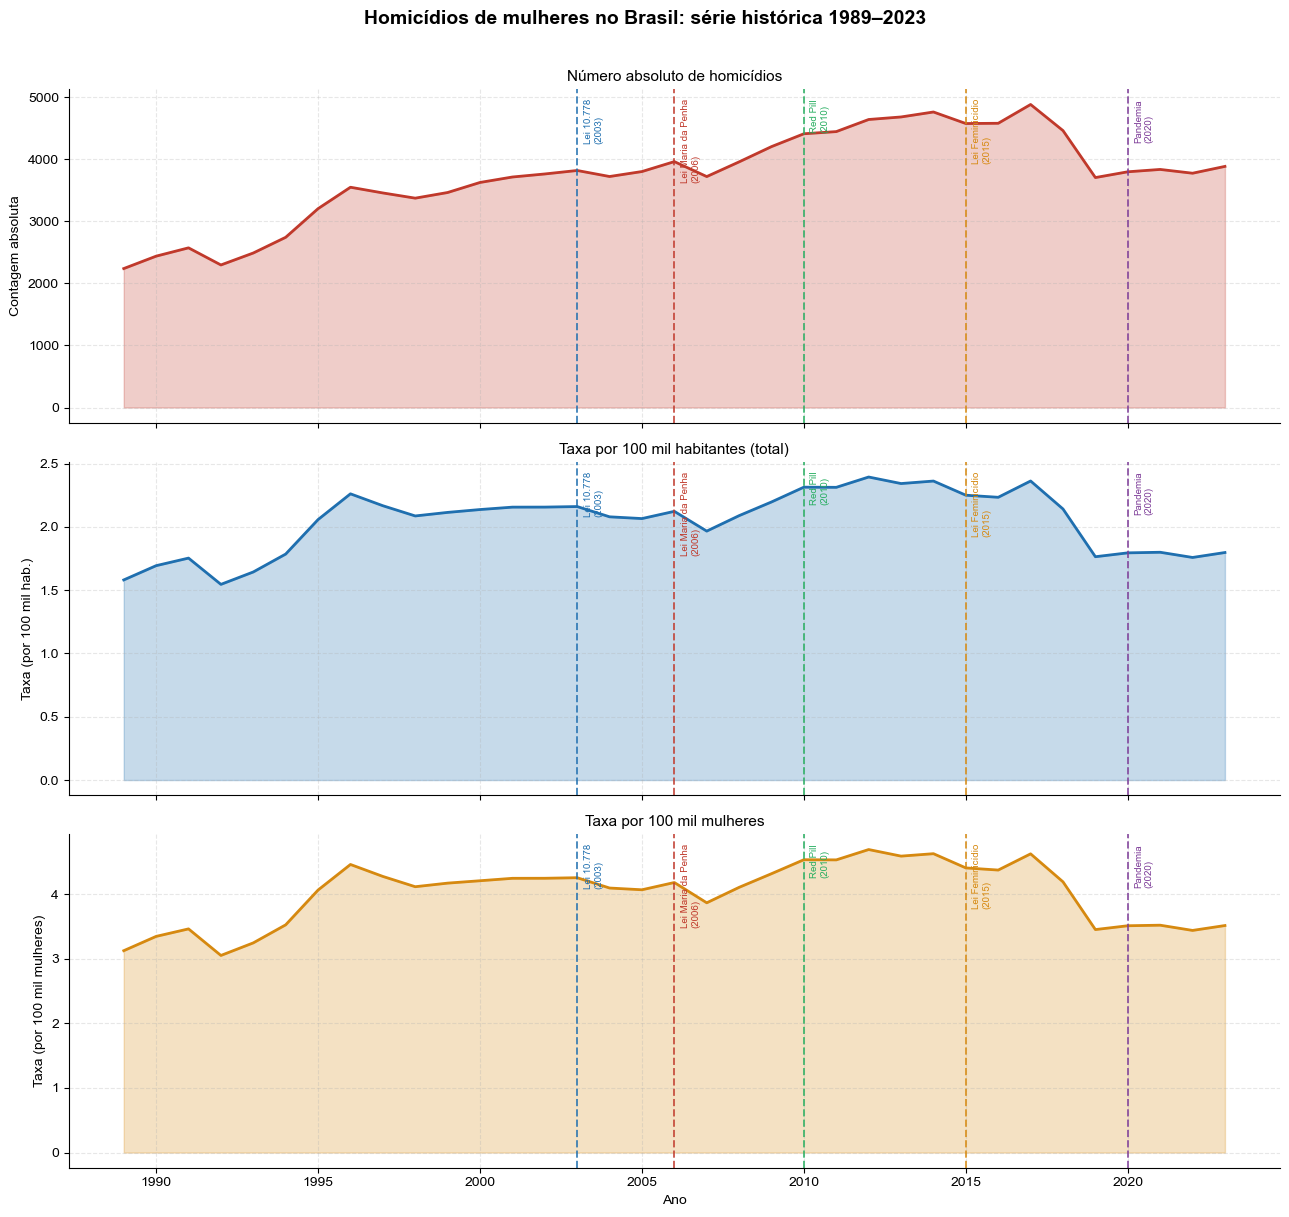

Figura 1 salva.


In [6]:
def adicionar_marcos(ax, ymin=None, ymax=None):
    ylim = ax.get_ylim()
    y0 = ymin if ymin is not None else ylim[0]
    y1 = ymax if ymax is not None else ylim[1]
    for m in MARCOS:
        ax.axvline(m['ano'], color=m['cor'], linewidth=1.4, linestyle='--', alpha=0.8)
        ax.text(m['ano'] + 0.2, y1 * 0.97, m['label'],
                fontsize=7, color=m['cor'], va='top', rotation=90)

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
fig.suptitle('Homicídios de mulheres no Brasil: série histórica 1989–2023',
             fontsize=14, fontweight='bold', y=1.01)

ax = axes[0]
ax.fill_between(df_brasil_mul['Ano'], df_brasil_mul['valor_brasil'], alpha=0.25, color='#C0392B')
ax.plot(df_brasil_mul['Ano'], df_brasil_mul['valor_brasil'], color='#C0392B', linewidth=2)
ax.set_ylabel('Contagem absoluta', fontsize=10)
ax.set_title('Número absoluto de homicídios', fontsize=11)
adicionar_marcos(ax)

ax = axes[1]
ax.fill_between(df_brasil_mul['Ano'], df_brasil_mul['taxa_100k_total'], alpha=0.25, color='#1F6FAF')
ax.plot(df_brasil_mul['Ano'], df_brasil_mul['taxa_100k_total'], color='#1F6FAF', linewidth=2)
ax.set_ylabel('Taxa (por 100 mil hab.)', fontsize=10)
ax.set_title('Taxa por 100 mil habitantes (total)', fontsize=11)
adicionar_marcos(ax)

ax = axes[2]
ax.fill_between(df_brasil_mul['Ano'], df_brasil_mul['taxa_100k_fem'], alpha=0.25, color='#D68910')
ax.plot(df_brasil_mul['Ano'], df_brasil_mul['taxa_100k_fem'], color='#D68910', linewidth=2)
ax.set_ylabel('Taxa (por 100 mil mulheres)', fontsize=10)
ax.set_title('Taxa por 100 mil mulheres', fontsize=11)
ax.set_xlabel('Ano', fontsize=10)
adicionar_marcos(ax)

plt.tight_layout()
plt.savefig('fig01_serie_historica_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 salva.')

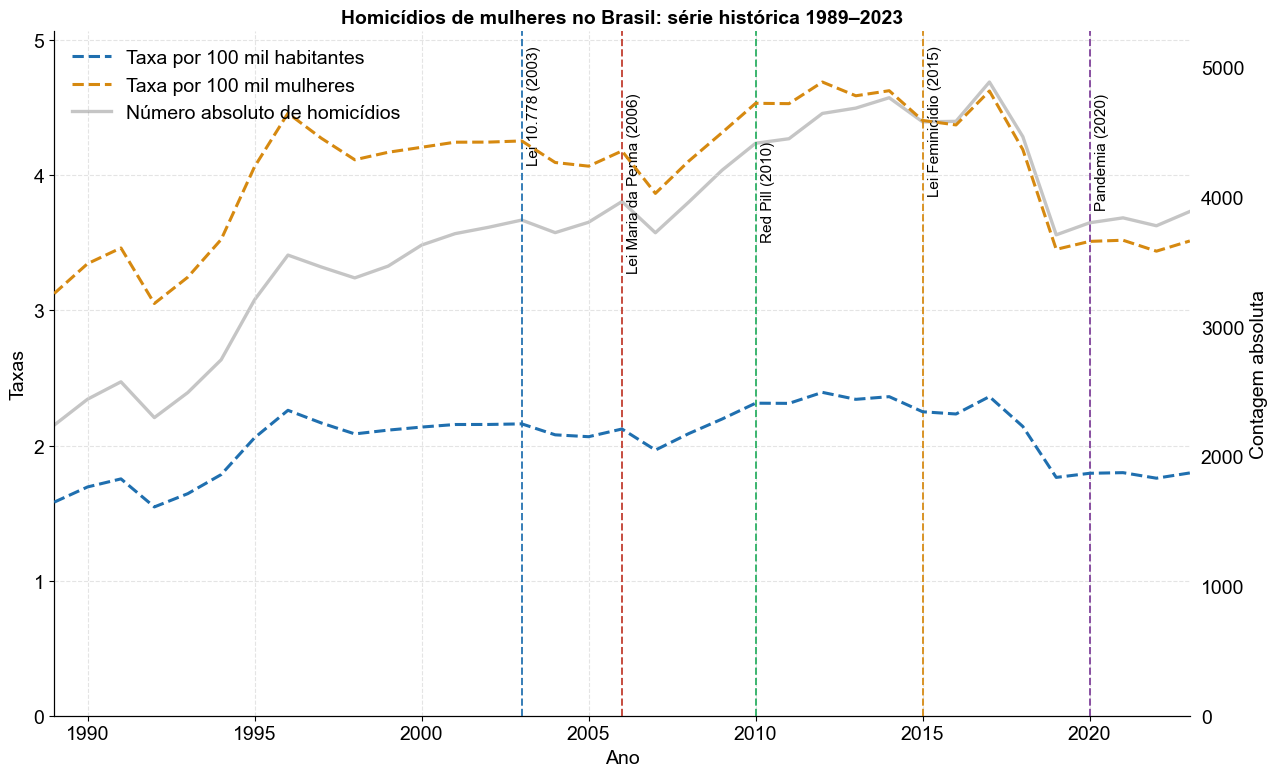

Figura 1b salva.


In [31]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'grid.color': '#D9D9D9',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8
})

def adicionar_marcos(ax):
    ymin, ymax = ax.get_ylim()
    alturas = [0.98, 0.91, 0.84]

    for i, m in enumerate(MARCOS):
        ax.axvline(
            x=m['ano'],
            color=m['cor'],
            linewidth=1.4,
            linestyle='--',
            alpha=0.9,
            zorder=2
        )
        ax.text(
            m['ano'] + 0.15,
            ymin + (ymax - ymin) * alturas[i % len(alturas)],
            m['label'],
            fontsize=11,
            color='black',
            rotation=90,
            va='top',
            ha='left'
        )

fig, ax1 = plt.subplots(figsize=(13, 8))
ax2 = ax1.twinx()

ax2.set_zorder(1)
ax1.set_zorder(2)
ax1.patch.set_alpha(0)

linha_abs, = ax2.plot(
    df_brasil_mul['Ano'],
    df_brasil_mul['valor_brasil'],
    color='gray',
    alpha=0.45,
    linewidth=2.4,
    linestyle='-',
    label='Número absoluto de homicídios',
    zorder=1
)

linha_taxa_total, = ax1.plot(
    df_brasil_mul['Ano'],
    df_brasil_mul['taxa_100k_total'],
    color='#1F6FAF',
    linewidth=2.2,
    linestyle='--',
    label='Taxa por 100 mil habitantes',
    zorder=4
)

linha_taxa_fem, = ax1.plot(
    df_brasil_mul['Ano'],
    df_brasil_mul['taxa_100k_fem'],
    color='#D68910',
    linewidth=2.2,
    linestyle='--',
    label='Taxa por 100 mil mulheres',
    zorder=5
)

ax1.set_title('Homicídios de mulheres no Brasil: série histórica 1989–2023', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Taxas')
ax2.set_ylabel('Contagem absoluta')

ax1.set_xlim(df_brasil_mul['Ano'].min(), df_brasil_mul['Ano'].max())

ax1.set_ylim(
    0,
    max(
        df_brasil_mul['taxa_100k_total'].max(),
        df_brasil_mul['taxa_100k_fem'].max()
    ) * 1.08
)

ax2.set_ylim(0, df_brasil_mul['valor_brasil'].max() * 1.08)

ax1.grid(True, axis='both', alpha=0.7)
ax2.grid(False)

for spine in ax1.spines.values():
    spine.set_color('black')

for spine in ax2.spines.values():
    spine.set_color('black')

ax1.tick_params(axis='both', colors='black')
ax2.tick_params(axis='y', colors='black', length=0, pad=8)

adicionar_marcos(ax1)

linhas = [linha_taxa_total, linha_taxa_fem, linha_abs]
labels = [l.get_label() for l in linhas]
leg = ax1.legend(linhas, labels, loc='upper left', frameon=False)

for text in leg.get_texts():
    text.set_color('black')

plt.tight_layout()
plt.savefig('fig01b_serie_historica_comparativa_linha_unica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1b salva.')

### 4.2 Taxa por 100 mil mulheres por região (série temporal)

As regiões brasileiras apresentam heterogeneidade estrutural expressiva. A normalização por 100 mil mulheres permite comparar regiões com populações de tamanhos muito distintos.

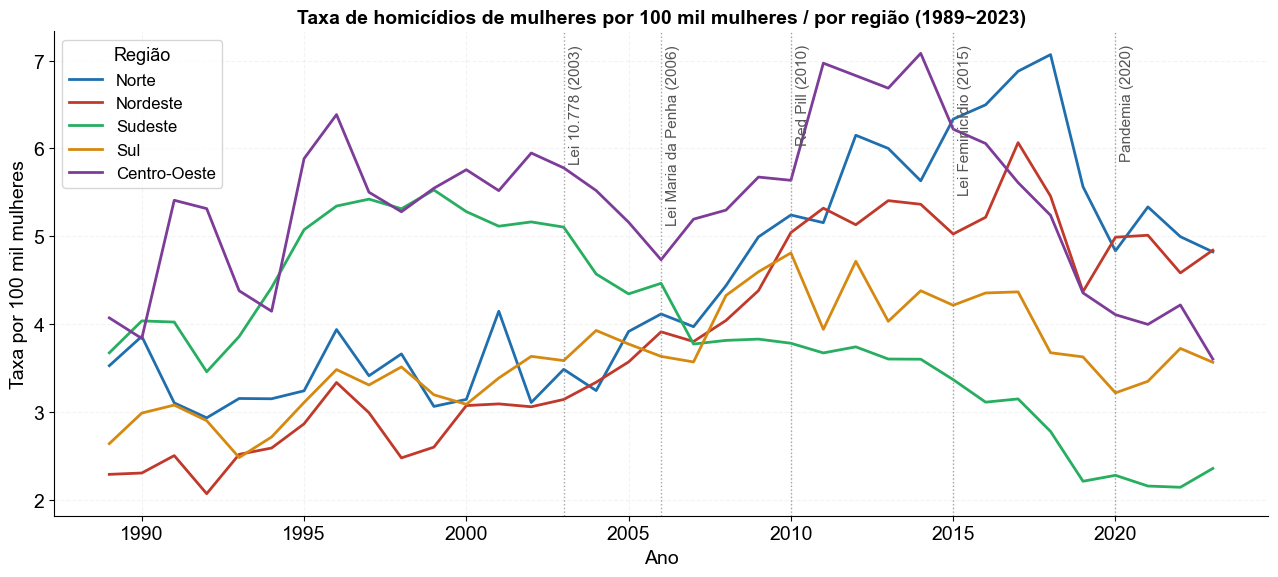

Figura 2 salva.


In [32]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

df_reg = (
    df_uf[df_uf['serie'] == 'homicidios_mulheres']
    .groupby(['Regiao', 'Ano'], as_index=False)
    .agg(valor_reg=('valor_uf', 'sum'), pop_fem=('Feminino', 'sum'), pop_total=('Total', 'sum'))
)
df_reg['taxa_100k_fem'] = df_reg['valor_reg'] / df_reg['pop_fem'] * 100_000

fig, ax = plt.subplots(figsize=(13, 6))

for regiao, cor in CORES_REGIAO.items():
    d = df_reg[df_reg['Regiao'] == regiao]
    ax.plot(d['Ano'], d['taxa_100k_fem'], label=regiao, color=cor, linewidth=2)

for m in MARCOS:
    ax.axvline(m['ano'], color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.text(
        m['ano'] + 0.15,
        ax.get_ylim()[1] * 0.98,
        m['label'],
        fontsize=11,
        fontfamily='Arial',
        color='#555555',
        va='top',
        rotation=90
    )

ax.set_title(
    'Taxa de homicídios de mulheres por 100 mil mulheres / por região (1989~2023)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=14)
ax.legend(title='Região', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.savefig('fig02_taxa_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 salva.')

### 4.3 Comparação múltiplas séries normalizadas (Brasil)

Análise conjunta das séries: mulheres, mulheres negras, mulheres não negras, jovens mulheres e homicídios por arma de fogo — todas expressas em taxa por 100 mil mulheres.

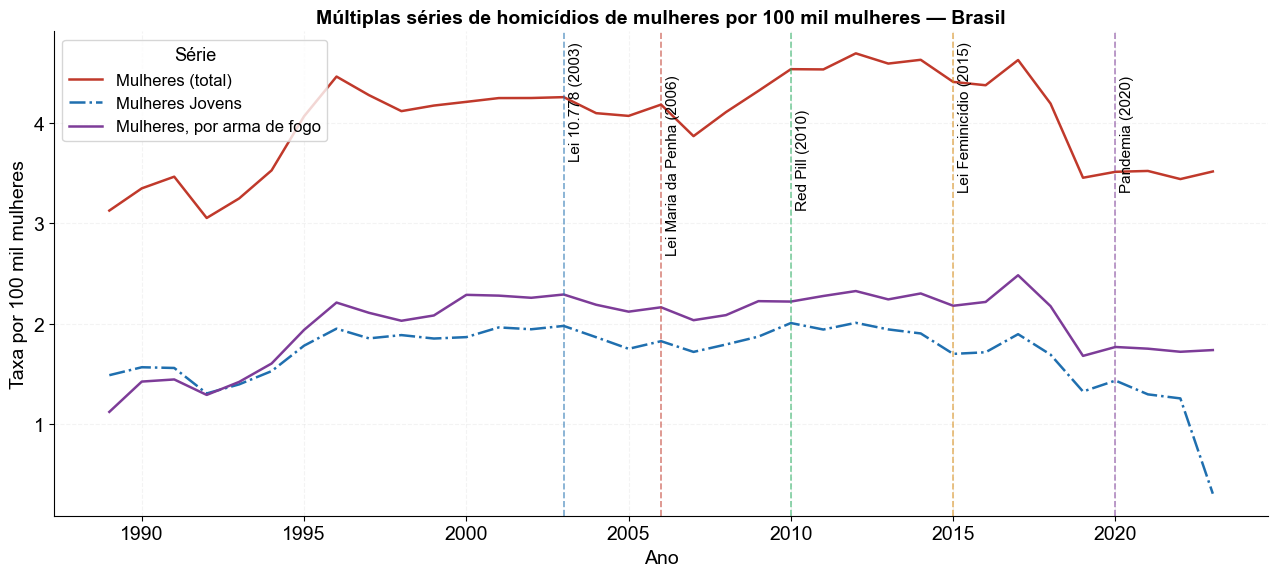

Figura 3 salva.


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

series_interesse = [
    ('homicidios_mulheres', 'Mulheres (total)', '#C0392B', '-'),
    #('homicidios_total', 'Homicídios (total)', '#922B21', '--'),
    ('homicidios_jovens_mulheres', 'Mulheres Jovens', '#1F6FAF', '-.'),
    ('homicidios_mulheres_armas_fogo', 'Mulheres, por arma de fogo', '#7D3C98', '-'),
]

fig, ax = plt.subplots(figsize=(13, 6))

for serie, rotulo, cor, ls in series_interesse:
    d = df_brasil[df_brasil['serie'] == serie].copy()
    if len(d) == 0:
        continue
    ax.plot(
        d['Ano'],
        d['taxa_100k_fem'],
        label=rotulo,
        color=cor,
        linewidth=1.8,
        linestyle=ls
    )

for m in MARCOS:
    ax.axvline(
        m['ano'],
        color=m['cor'],
        linewidth=1.2,
        linestyle='--',
        alpha=0.6
    )

ymin, ymax = ax.get_ylim()
alturas = [0.98, 0.91, 0.84]

for i, m in enumerate(MARCOS):
    ax.text(
        m['ano'] + 0.15,
        ymin + (ymax - ymin) * alturas[i % len(alturas)],
        m['label'],
        fontsize=11,
        fontfamily='Arial',
        color='black',
        va='top',
        rotation=90
    )

ax.legend(title='Série', fontsize=12, title_fontsize=13, loc='upper left')

ax.set_title(
    'Múltiplas séries de homicídios de mulheres por 100 mil mulheres — Brasil',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=14)

plt.tight_layout()
plt.savefig('fig03_multiplas_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 salva.')

### 4.4 Heatmap: taxa por 100 mil mulheres por estado (todos os anos)

O heatmap permite identificar padrões estruturais por estado ao longo do tempo. Estados com altas taxas persistentes e aqueles com mudanças abruptas ficam visualmente destacados.

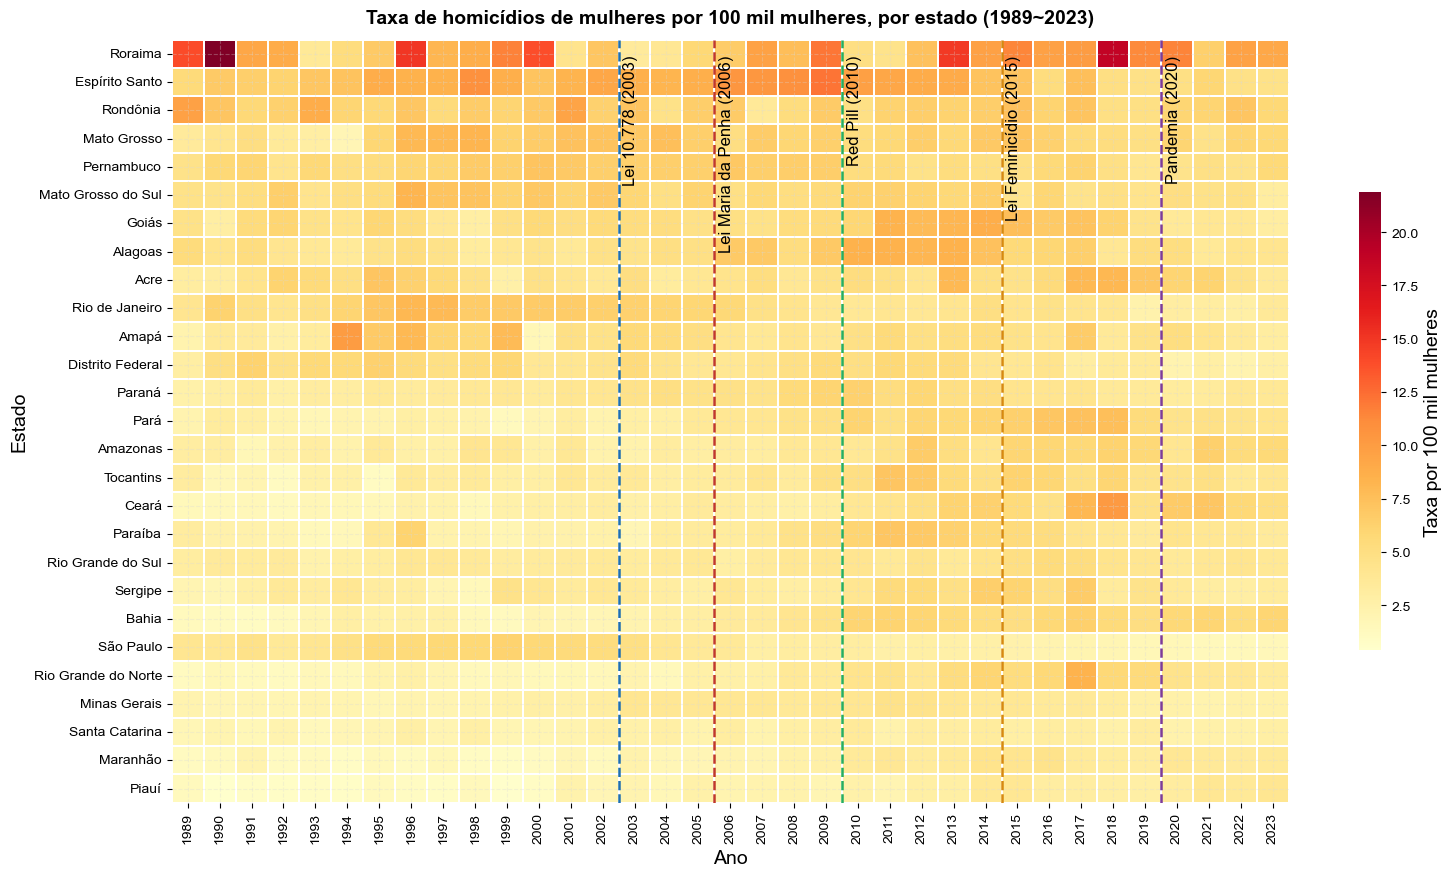

Figura 4 salva.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

df_hm = (
    df_uf[df_uf['serie'] == 'homicidios_mulheres']
    [['Estado', 'Ano', 'taxa_100k_fem']]
    .pivot(index='Estado', columns='Ano', values='taxa_100k_fem')
)

ordem = df_hm.mean(axis=1).sort_values(ascending=False).index
df_hm = df_hm.loc[ordem]

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    df_hm,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Taxa por 100 mil mulheres', 'shrink': 0.6},
    fmt='.1f',
    annot=False
)

anos = list(df_hm.columns)

for m in MARCOS:
    if m['ano'] in anos:
        pos_x = anos.index(m['ano'])
        ax.axvline(pos_x, color=m['cor'], linewidth=1.8, linestyle='--')
        ax.text(
            pos_x + 0.15,
            0.98,
            m['label'],
            transform=ax.get_xaxis_transform(),
            fontsize=12,
            fontfamily='Arial',
            color='black',
            rotation=90,
            va='top',
            ha='left'
        )

ax.set_title(
    'Taxa de homicídios de mulheres por 100 mil mulheres, por estado (1989~2023)',
    fontsize=14,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Estado', fontsize=14)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Taxa por 100 mil mulheres', fontsize=14)

plt.tight_layout()
plt.savefig('fig04_heatmap_estado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 salva.')

### 4.5 Boxplot por UF antes e depois dos marcos (taxa por 100 mil mulheres)

Para cada marco, compara-se a distribuição da taxa entre os 5 anos anteriores e os 5 anos posteriores ao evento. O teste de Mann-Whitney é aplicado para verificar se há diferença estatisticamente significativa entre os períodos.

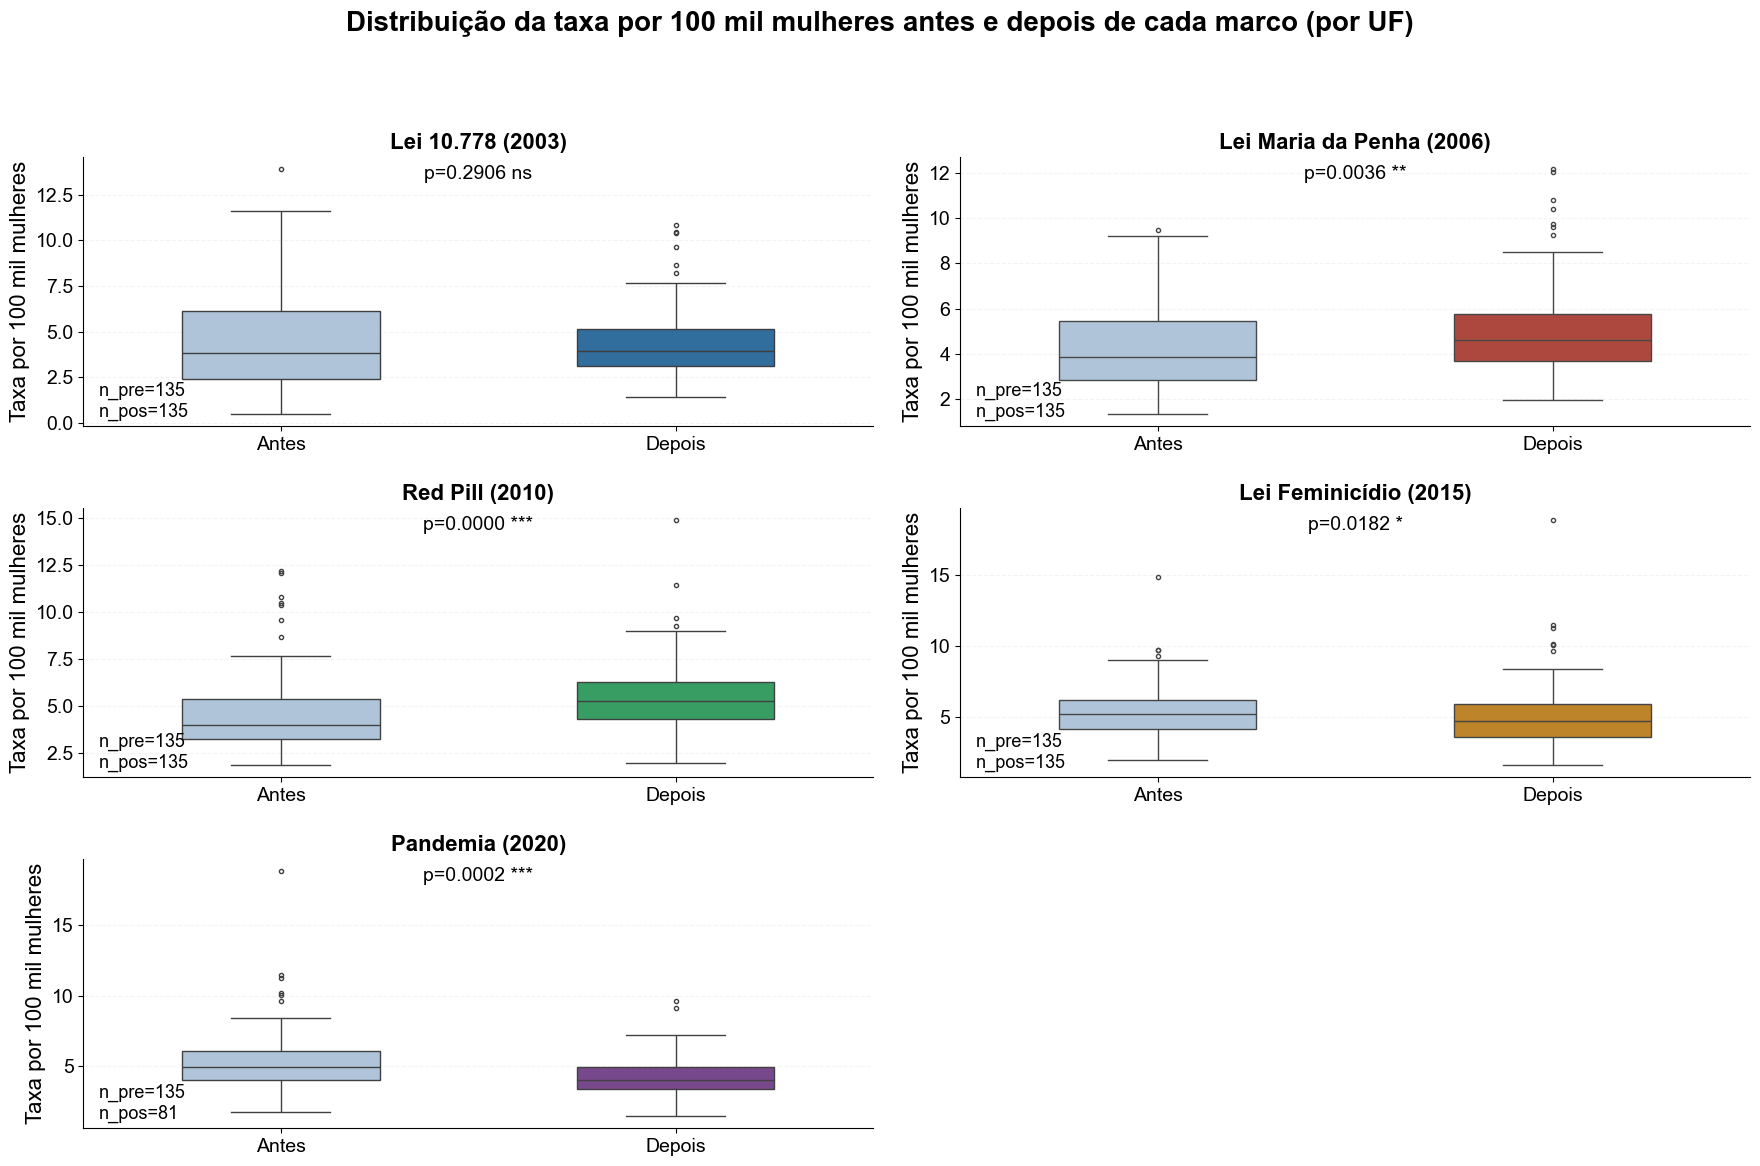

Figura 5 salva.


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 20,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

JANELA = 5

df_mul = df_uf[df_uf['serie'] == 'homicidios_mulheres'].copy()

fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharey=False)
axes = axes.flatten()

fig.suptitle(
    'Distribuição da taxa por 100 mil mulheres antes e depois de cada marco (por UF)',
    fontsize=20,
    fontweight='bold'
)

for ax, marco in zip(axes, MARCOS):

    ano = marco['ano']
    anos_pre = list(range(ano - JANELA, ano))
    anos_pos = list(range(ano + 1, ano + JANELA + 1))
    anos_pos = [a for a in anos_pos if a <= df_mul['Ano'].max()]

    pre = df_mul[df_mul['Ano'].isin(anos_pre)]['taxa_100k_fem'].dropna()
    pos = df_mul[df_mul['Ano'].isin(anos_pos)]['taxa_100k_fem'].dropna()

    stat, pval = stats.mannwhitneyu(pre, pos, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))

    dados = pd.DataFrame({
        'taxa': pd.concat([pre, pos], ignore_index=True),
        'periodo': ['Antes'] * len(pre) + ['Depois'] * len(pos)
    })

    sns.boxplot(
        data=dados,
        x='periodo',
        y='taxa',
        palette={'Antes': '#A8C4E0', 'Depois': marco['cor']},
        order=['Antes', 'Depois'],
        ax=ax,
        width=0.5,
        fliersize=3
    )

    ax.set_title(
        marco['label'].replace('\n', ' '),
        fontsize=16,
        fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=16)

    ax.text(
        0.5, 0.97,
        f'p={pval:.4f} {sig}',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=14,
        color='black'
    )

    ax.annotate(
        f'n_pre={len(pre)}\nn_pos={len(pos)}',
        xy=(0.02, 0.02),
        xycoords='axes fraction',
        fontsize=13,
        color='black',
        va='bottom'
    )

    ax.tick_params(axis='both', labelsize=14)

for ax in axes[len(MARCOS):]:
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig05_boxplot_marcos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 salva.')

### 4.6 Variação percentual da taxa: período anterior vs. posterior a cada marco

Calculada como a diferença percentual entre a média da taxa nos 5 anos após o marco e a média dos 5 anos antes, por região. Valores negativos indicam redução.

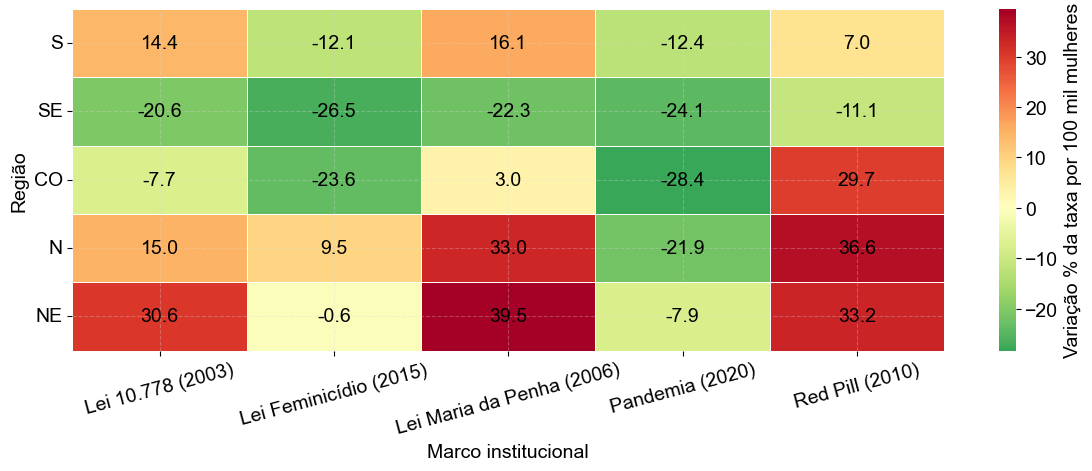

Figura 6 salva.
Marco   Lei 10.778 (2003)  Lei Feminicídio (2015)  Lei Maria da Penha (2006)  Pandemia (2020)  Red Pill (2010)
Regiao                                                                                                        
S                    14.4                   -12.1                       16.1            -12.4              7.0
SE                  -20.6                   -26.5                      -22.3            -24.1            -11.1
CO                   -7.7                   -23.6                        3.0            -28.4             29.7
N                    15.0                     9.5                       33.0            -21.9             36.6
NE                   30.6                    -0.6                       39.5             -7.9             33.2


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

resultados = []

for marco in MARCOS:
    ano = marco['ano']
    anos_pre = list(range(ano - JANELA, ano))
    anos_pos = list(range(ano + 1, ano + JANELA + 1))
    anos_pos = [a for a in anos_pos if a <= df_mul['Ano'].max()]

    for regiao in MAPA_REGIAO.values():
        d_reg = df_reg[df_reg['Regiao'] == regiao]
        media_pre = d_reg[d_reg['Ano'].isin(anos_pre)]['taxa_100k_fem'].mean()
        media_pos = d_reg[d_reg['Ano'].isin(anos_pos)]['taxa_100k_fem'].mean()

        if media_pre > 0:
            var_pct = (media_pos - media_pre) / media_pre * 100
        else:
            var_pct = np.nan

        resultados.append({
            'Marco': marco['label'].replace('\n', ' '),
            'Regiao': regiao,
            'Media_pre': media_pre,
            'Media_pos': media_pos,
            'Variacao_pct': var_pct
        })

df_var = pd.DataFrame(resultados).drop_duplicates()

pivot = df_var.pivot(index='Regiao', columns='Marco', values='Variacao_pct')

mapa_siglas = {
    'Sul': 'S',
    'Sudeste': 'SE',
    'Centro-Oeste': 'CO',
    'Norte': 'N',
    'Nordeste': 'NE'
}

ordem_regioes = ['S', 'SE', 'CO', 'N', 'NE']

pivot = pivot.rename(index=mapa_siglas)
pivot = pivot.reindex(ordem_regioes)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Variação % da taxa por 100 mil mulheres'},
    annot_kws={'fontsize': 14, 'color': 'black'}
)


ax.set_xlabel('Marco institucional', fontsize=14)
ax.set_ylabel('Região', fontsize=14)
ax.tick_params(axis='x', rotation=15, labelsize=14)
ax.tick_params(axis='y', rotation=0, labelsize=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Variação % da taxa por 100 mil mulheres', fontsize=14)

plt.tight_layout()
plt.savefig('fig06_variacao_marcos_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 salva.')
print(pivot.round(1).to_string())

### 4.7 Negras vs. não negras — taxa por 100 mil mulheres (Brasil)

A desagregação racial é disponível a partir de anos mais recentes nos dados do Atlas da Violência. Esta visualização evidencia a diferença estrutural de risco entre mulheres negras e não negras.

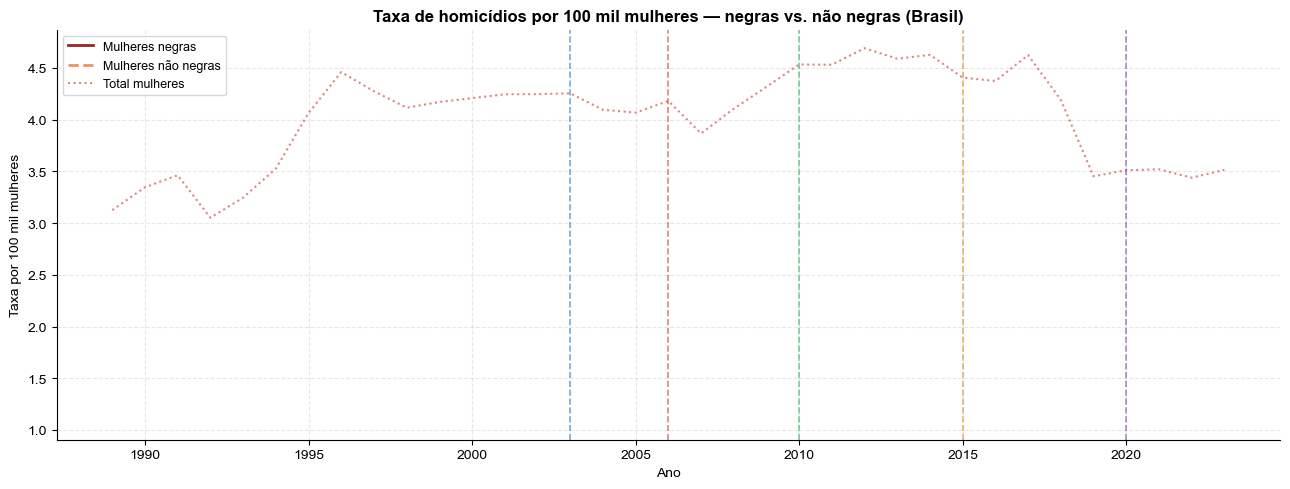

Figura 7 salva.


In [12]:
df_negras   = df_brasil[df_brasil['serie'] == 'homicidios_mulheres_negras']
df_nao_neg  = df_brasil[df_brasil['serie'] == 'homicidios_mulheres_nao_negras']
df_mul_br   = df_brasil[df_brasil['serie'] == 'homicidios_mulheres']

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_negras['Ano'],  df_negras['taxa_100k_fem'],  color='#922B21', linewidth=2,
        label='Mulheres negras')
ax.plot(df_nao_neg['Ano'], df_nao_neg['taxa_100k_fem'], color='#E59866', linewidth=2,
        linestyle='--', label='Mulheres não negras')
ax.plot(df_mul_br['Ano'],  df_mul_br['taxa_100k_fem'],  color='#C0392B', linewidth=1.5,
        linestyle=':', label='Total mulheres', alpha=0.6)

for m in MARCOS:
    ax.axvline(m['ano'], color=m['cor'], linewidth=1.2, linestyle='--', alpha=0.6)

ax.set_title('Taxa de homicídios por 100 mil mulheres — negras vs. não negras (Brasil)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano', fontsize=10)
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig07_negras_nao_negras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 7 salva.')

### 4.8 Participação de armas de fogo nos homicídios de mulheres

Razão entre homicídios de mulheres por arma de fogo e homicídios totais de mulheres, expressa como percentual. Indica a evolução do padrão instrumental da violência letal.

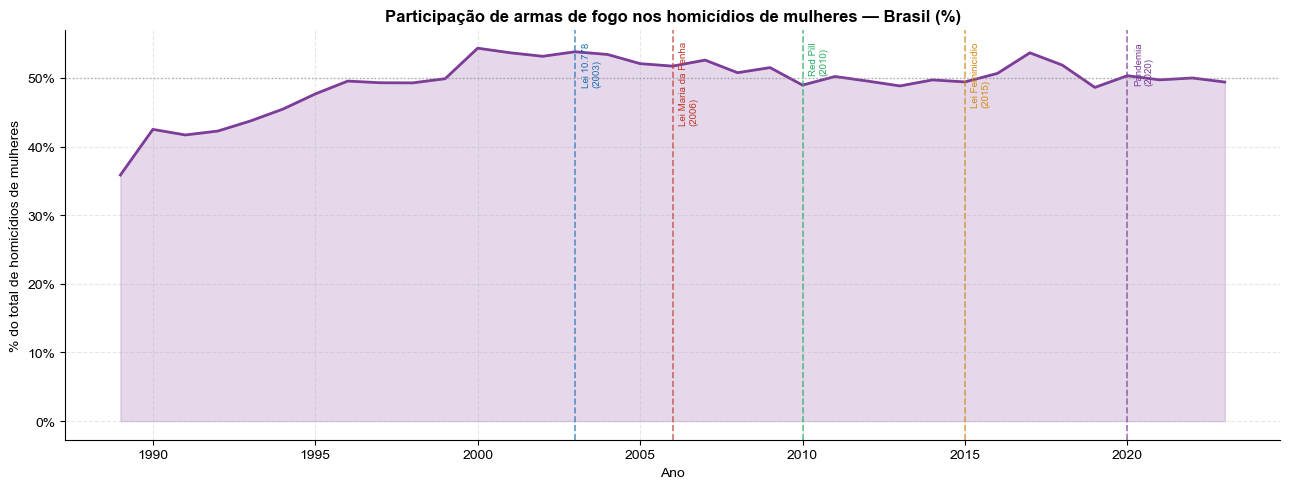

Figura 8 salva.


In [13]:
df_armas_br = df_brasil[df_brasil['serie'] == 'homicidios_mulheres_armas_fogo']

df_prop = df_mul_br[['Ano', 'valor_brasil']].merge(
    df_armas_br[['Ano', 'valor_brasil']],
    on='Ano', suffixes=('_total', '_armas')
)
df_prop['prop_armas'] = df_prop['valor_brasil_armas'] / df_prop['valor_brasil_total'] * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(df_prop['Ano'], df_prop['prop_armas'], alpha=0.2, color='#7D3C98')
ax.plot(df_prop['Ano'], df_prop['prop_armas'], color='#7D3C98', linewidth=2)
ax.axhline(50, color='gray', linewidth=1, linestyle=':', alpha=0.6)

for m in MARCOS:
    ax.axvline(m['ano'], color=m['cor'], linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(m['ano'] + 0.2, ax.get_ylim()[1] * 0.97, m['label'],
            fontsize=7, color=m['cor'], va='top', rotation=90)

ax.set_title('Participação de armas de fogo nos homicídios de mulheres — Brasil (%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano', fontsize=10)
ax.set_ylabel('% do total de homicídios de mulheres', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('fig08_proporcao_armas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 8 salva.')

### 4.9 Ranking de estados: taxa média por 100 mil mulheres (2019–2023)

Média da taxa no quinquênio mais recente disponível para identificar os estados com maior vulnerabilidade atual.

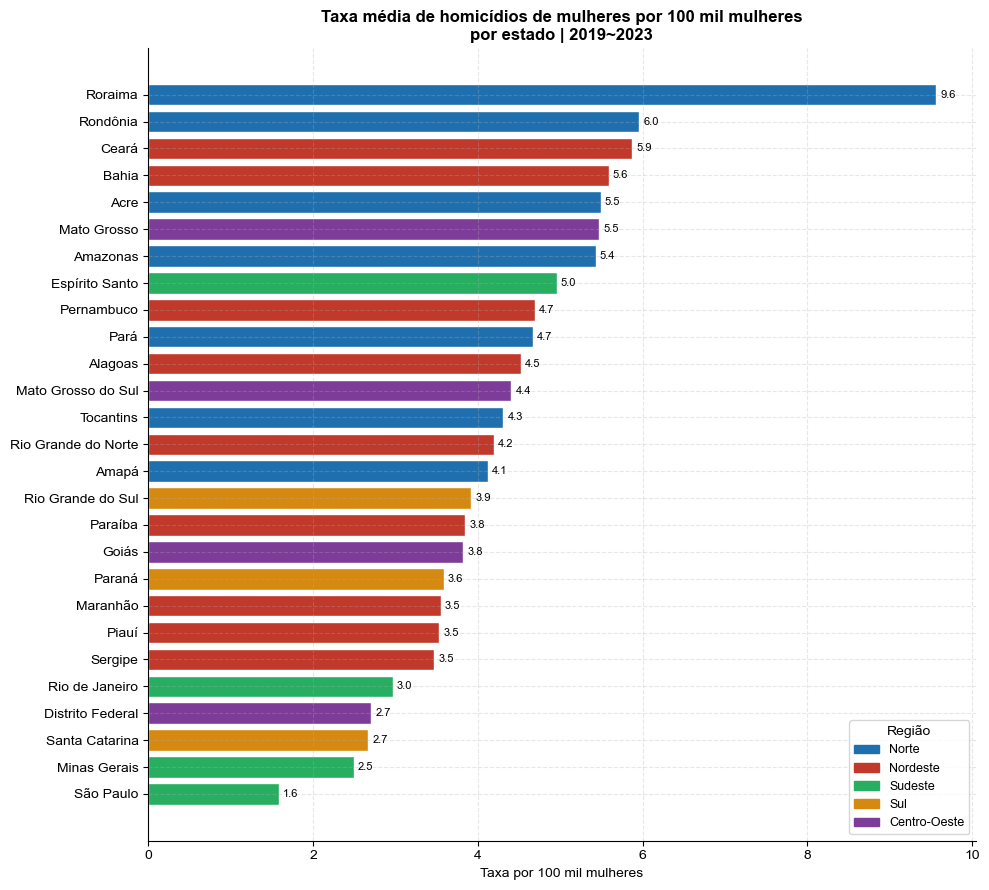

Figura 9 salva.


In [14]:
anos_recentes = list(range(2019, 2024))

df_rank = (
    df_mul[df_mul['Ano'].isin(anos_recentes)]
    .groupby('Estado', as_index=False)
    .agg(taxa_media=('taxa_100k_fem', 'mean'))
    .sort_values('taxa_media', ascending=True)
)
df_rank['Regiao'] = df_rank['Estado'].map(MAPA_REGIAO)

cores_barras = [CORES_REGIAO[r] for r in df_rank['Regiao']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(df_rank['Estado'], df_rank['taxa_media'], color=cores_barras, edgecolor='white')

for bar, val in zip(bars, df_rank['taxa_media']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', ha='left', fontsize=8)

patches_leg = [mpatches.Patch(color=cor, label=reg) for reg, cor in CORES_REGIAO.items()]
ax.legend(handles=patches_leg, title='Região', fontsize=9, loc='lower right')

ax.set_title(f'Taxa média de homicídios de mulheres por 100 mil mulheres\npor estado | {anos_recentes[0]}~{anos_recentes[-1]}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Taxa por 100 mil mulheres', fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig09_ranking_estados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 9 salva.')

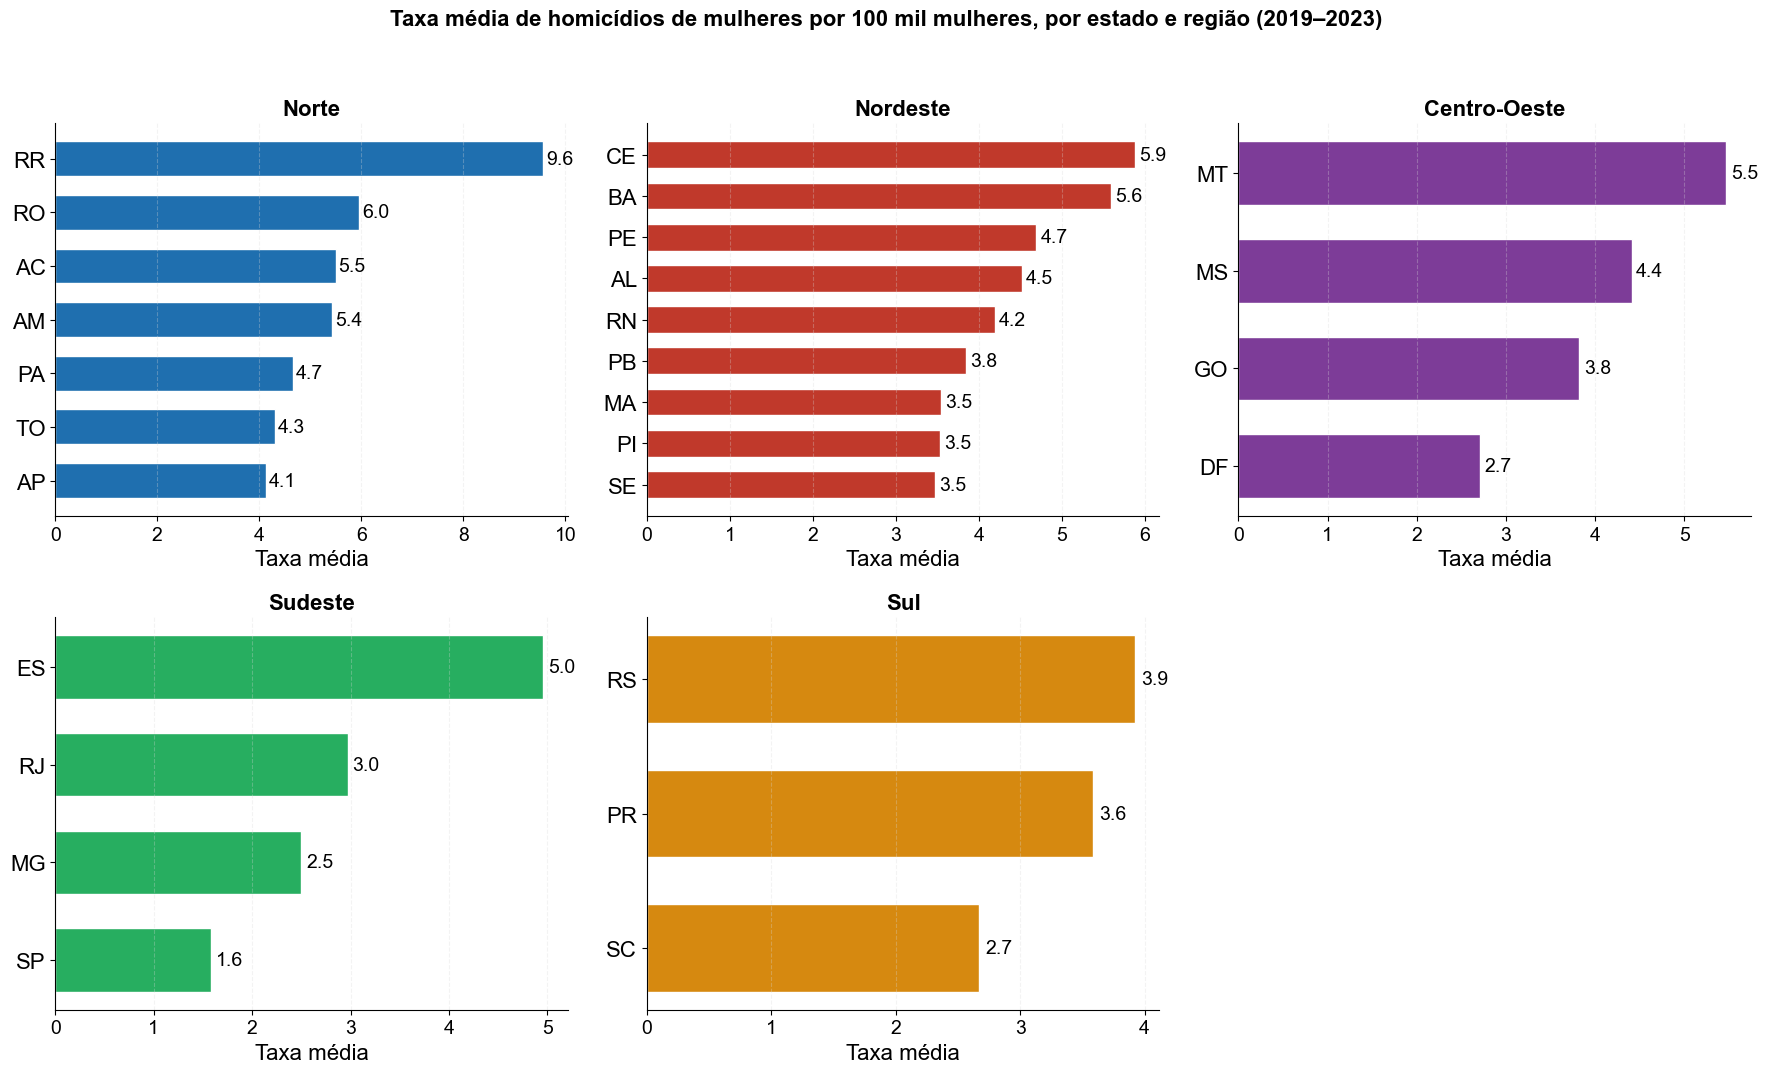

Figura 9 salva.


In [66]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

MAPA_UF_SIGLA = {
    'Acre': 'AC',
    'Alagoas': 'AL',
    'Amapá': 'AP',
    'Amazonas': 'AM',
    'Bahia': 'BA',
    'Ceará': 'CE',
    'Distrito Federal': 'DF',
    'Espírito Santo': 'ES',
    'Goiás': 'GO',
    'Maranhão': 'MA',
    'Mato Grosso': 'MT',
    'Mato Grosso do Sul': 'MS',
    'Minas Gerais': 'MG',
    'Pará': 'PA',
    'Paraíba': 'PB',
    'Paraná': 'PR',
    'Pernambuco': 'PE',
    'Piauí': 'PI',
    'Rio de Janeiro': 'RJ',
    'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS',
    'Rondônia': 'RO',
    'Roraima': 'RR',
    'Santa Catarina': 'SC',
    'São Paulo': 'SP',
    'Sergipe': 'SE',
    'Tocantins': 'TO'
}

anos_recentes = list(range(2019, 2024))

df_rank = (
    df_mul[df_mul['Ano'].isin(anos_recentes)]
    .groupby('Estado', as_index=False)
    .agg(taxa_media=('taxa_100k_fem', 'mean'))
)

df_rank['Regiao'] = df_rank['Estado'].map(MAPA_REGIAO)
df_rank['UF'] = df_rank['Estado'].map(MAPA_UF_SIGLA).fillna(df_rank['Estado'])

ordem_regioes = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, regiao in enumerate(ordem_regioes):
    ax = axes[i]
    d = (
        df_rank[df_rank['Regiao'] == regiao]
        .sort_values('taxa_media', ascending=True)
        .reset_index(drop=True)
    )

    cor = CORES_REGIAO[regiao]
    bars = ax.barh(
        d['UF'],
        d['taxa_media'],
        color=cor,
        edgecolor='white',
        height=0.65
    )

    for bar, val in zip(bars, d['taxa_media']):
        ax.text(
            val + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}',
            va='center',
            ha='left',
            fontsize=14,
            color='black'
        )

    ax.set_title(regiao, fontsize=16, fontweight='bold')
    ax.set_xlabel('Taxa média', fontsize=16)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.grid(axis='y', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[5].axis('off')

fig.suptitle(
    f'Taxa média de homicídios de mulheres por 100 mil mulheres, por estado e região ({anos_recentes[0]}–{anos_recentes[-1]})',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig09_ranking_estados_regioes_barras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 9 salva.')

---

## 5. Tabela síntese estatística

Estatísticas descritivas da taxa por 100 mil mulheres para o Brasil, por período entre marcos.

In [15]:
anos_marcos_sorted = sorted([m['ano'] for m in MARCOS])
limites = [1989] + anos_marcos_sorted + [2023]
rotulos = []
for i in range(len(limites) - 1):
    rotulos.append(f'{limites[i]}–{limites[i+1]-1}')

df_brasil_mul2 = df_brasil_mul.copy()
df_brasil_mul2['periodo_label'] = pd.cut(
    df_brasil_mul2['Ano'],
    bins=limites,
    labels=rotulos,
    right=False,
    include_lowest=True
)

tabela = (
    df_brasil_mul2
    .groupby('periodo_label', observed=True)
    .agg(
        Media_taxa_100k_fem=('taxa_100k_fem', 'mean'),
        Min=('taxa_100k_fem', 'min'),
        Max=('taxa_100k_fem', 'max'),
        Desvio_padrao=('taxa_100k_fem', 'std'),
        Media_abs=('valor_brasil', 'mean')
    )
    .round(2)
)

print('Estatísticas por período entre marcos — homicídios de mulheres (Brasil):')
print(tabela.to_string())

Estatísticas por período entre marcos — homicídios de mulheres (Brasil):
               Media_taxa_100k_fem   Min   Max  Desvio_padrao  Media_abs
periodo_label                                                           
1989–2002                     3.82  3.05  4.46           0.50    3068.07
2003–2005                     4.14  4.07  4.25           0.10    3783.00
2006–2009                     4.12  3.87  4.32           0.19    3963.25
2010–2014                     4.59  4.53  4.69           0.07    4590.40
2015–2019                     4.21  3.45  4.62           0.45    4443.20
2020–2022                     3.49  3.44  3.52           0.04    3805.00


---

## 6. Considerações metodológicas

- **Interpolação da população:** os dados do IBGE disponíveis são censos (1991, 2000, 2010, 2022), contagens (1996) e estimativas intercensitárias. O arquivo `populacao_consolidada.xlsx` consolida essas estimativas anuais por UF, permitindo a normalização ano a ano.
- **Taxa por 100 mil mulheres vs. por 100 mil habitantes:** a taxa feminina é preferível para analisar violência contra a mulher pois evita a diluição causada pela parcela masculina da população, que não está no denominador de risco para esse tipo de evento.
- **Dados de raça/cor:** disponíveis apenas para períodos mais recentes no Atlas da Violência, o que limita a extensão histórica da análise racial.
- **Causalidade:** as análises de 'antes e depois' dos marcos são descritivas. Correlação temporal com marcos legais não implica causalidade; múltiplos fatores socioeconômicos coatuam simultaneamente.
- **Teste de Mann-Whitney:** foi escolhido por ser não paramétrico, adequado para distribuições assimétricas (como taxas de violência por estado) e amostras de tamanho moderado.

TABELA 1 — Média da taxa por 100 mil mulheres: antes vs. depois (Brasil)
                    Marco  Anos antes (1998–2002)  Anos depois (2004–2008)  Variação (%)  p-valor (MW) Sig.  Anos antes (2001–2005)  Anos depois (2007–2011)  Anos antes (2005–2009)  Anos depois (2011–2015)  Anos antes (2010–2014)  Anos depois (2016–2020)  Anos antes (2015–2019)  Anos depois (2021–2023)
        Lei 10.778 (2003)                     4.2                     4.06          -3.2        0.2906   ns                     NaN                      NaN                     NaN                      NaN                     NaN                      NaN                     NaN                      NaN
Lei Maria da Penha (2006)                     NaN                      NaN           2.1        0.0036   **                    4.18                     4.27                     NaN                      NaN                     NaN                      NaN                     NaN                      NaN
          Red P

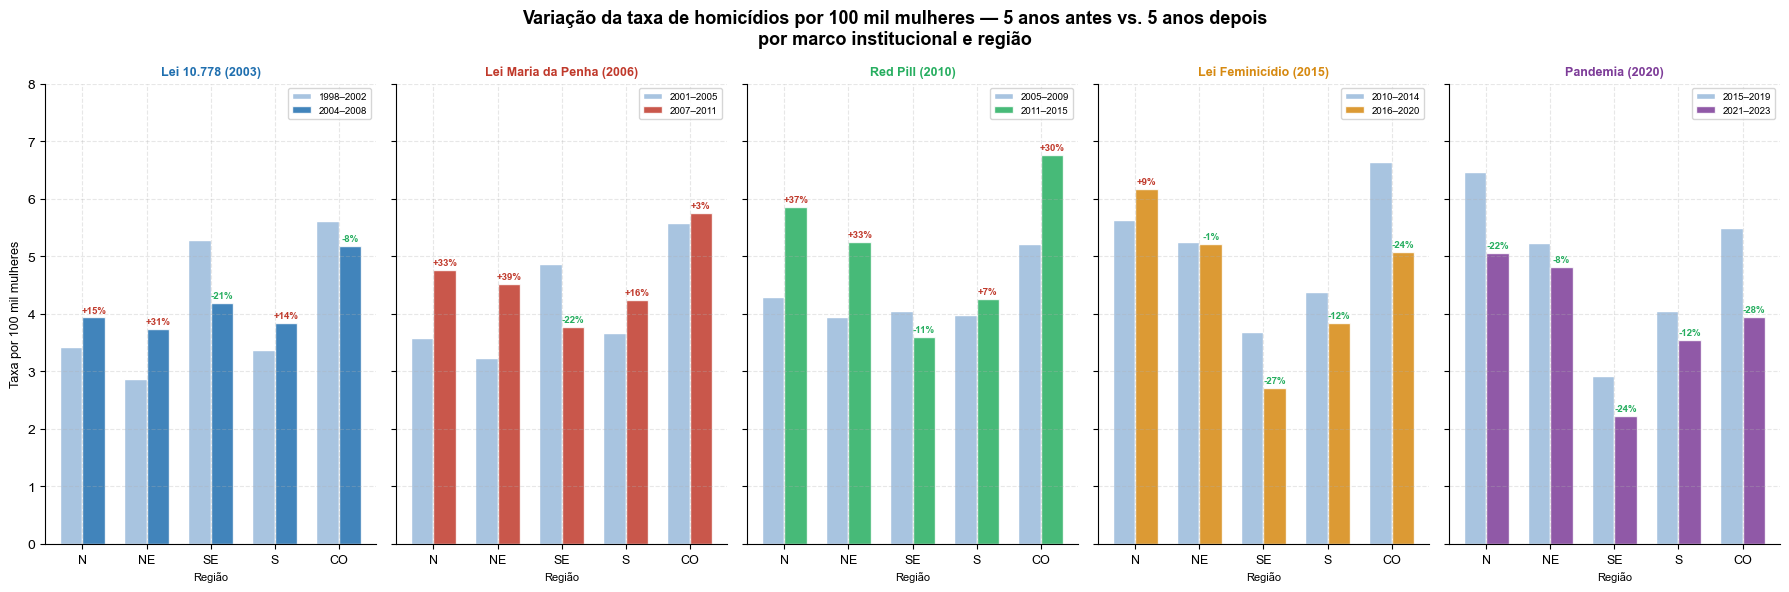


Figura salva: fig_antes_depois_marcos.png


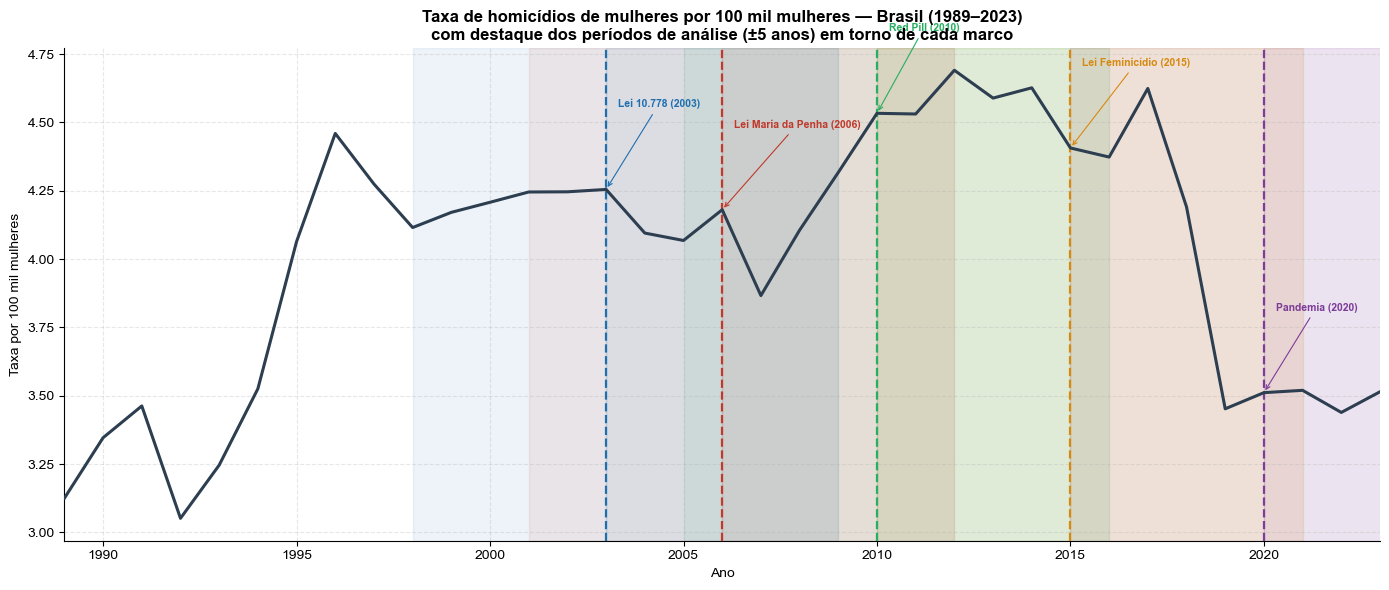

Figura salva: fig_linha_tempo_marcos.png


In [16]:
# ============================================================
# Análise antes/depois de cada marco — taxa por 100 mil mulheres
# Parâmetro: média dos 5 anos anteriores vs. 5 anos posteriores
# ============================================================

from scipy import stats

JANELA = 5

MARCOS = [
    {'ano': 2003, 'label': 'Lei 10.778 (2003)',       'cor': '#1F6FAF'},
    {'ano': 2006, 'label': 'Lei Maria da Penha (2006)', 'cor': '#C0392B'},
    {'ano': 2010, 'label': 'Red Pill (2010)',           'cor': '#27AE60'},
    {'ano': 2015, 'label': 'Lei Feminicídio (2015)',    'cor': '#D68910'},
    {'ano': 2020, 'label': 'Pandemia (2020)',           'cor': '#7D3C98'},
]

df_mul = df_uf[df_uf['serie'] == 'homicidios_mulheres'].copy()

# ------------------------------------------------------------------
# 1. Tabela síntese nacional: média antes x depois de cada marco
# ------------------------------------------------------------------

registros = []

for m in MARCOS:
    ano = m['ano']
    anos_pre = list(range(ano - JANELA, ano))
    anos_pos = list(range(ano + 1, ano + JANELA + 1))
    anos_pos = [a for a in anos_pos if a <= df_mul['Ano'].max()]

    serie_br = df_brasil[df_brasil['serie'] == 'homicidios_mulheres']

    media_pre_br = serie_br[serie_br['Ano'].isin(anos_pre)]['taxa_100k_fem'].mean()
    media_pos_br = serie_br[serie_br['Ano'].isin(anos_pos)]['taxa_100k_fem'].mean()
    var_pct = (media_pos_br - media_pre_br) / media_pre_br * 100

    vals_pre_uf = df_mul[df_mul['Ano'].isin(anos_pre)]['taxa_100k_fem'].dropna()
    vals_pos_uf = df_mul[df_mul['Ano'].isin(anos_pos)]['taxa_100k_fem'].dropna()
    stat, pval = stats.mannwhitneyu(vals_pre_uf, vals_pos_uf, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))

    registros.append({
        'Marco': m['label'],
        f'Anos antes ({ano-JANELA}–{ano-1})': round(media_pre_br, 2),
        f'Anos depois ({ano+1}–{min(ano+JANELA, 2023)})': round(media_pos_br, 2),
        'Variação (%)': round(var_pct, 1),
        'p-valor (MW)': round(pval, 4),
        'Sig.': sig,
    })

df_sintese = pd.DataFrame(registros)
print('=' * 80)
print('TABELA 1 — Média da taxa por 100 mil mulheres: antes vs. depois (Brasil)')
print('=' * 80)
print(df_sintese.to_string(index=False))


# ------------------------------------------------------------------
# 2. Tabela por região para cada marco
# ------------------------------------------------------------------

print('\n')
print('=' * 80)
print('TABELA 2 — Variação % da taxa por 100 mil mulheres por REGIÃO × MARCO')
print('=' * 80)

ordem_regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

df_reg = (
    df_mul
    .groupby(['Regiao', 'Ano'], as_index=False)
    .agg(valor_reg=('valor_uf', 'sum'), pop_fem=('Feminino', 'sum'))
)
df_reg['taxa_100k_fem'] = df_reg['valor_reg'] / df_reg['pop_fem'] * 100_000

linhas = []
for regiao in ordem_regioes:
    linha = {'Região': regiao}
    d = df_reg[df_reg['Regiao'] == regiao]
    for m in MARCOS:
        ano = m['ano']
        anos_pre = list(range(ano - JANELA, ano))
        anos_pos = list(range(ano + 1, ano + JANELA + 1))
        anos_pos = [a for a in anos_pos if a <= df_mul['Ano'].max()]
        media_pre = d[d['Ano'].isin(anos_pre)]['taxa_100k_fem'].mean()
        media_pos = d[d['Ano'].isin(anos_pos)]['taxa_100k_fem'].mean()
        var = (media_pos - media_pre) / media_pre * 100 if media_pre > 0 else np.nan
        linha[m['label']] = f'{var:+.1f}%'
    linhas.append(linha)

df_reg_var = pd.DataFrame(linhas)
print(df_reg_var.to_string(index=False))


# ------------------------------------------------------------------
# 3. Tabela por estado para cada marco — ordenada pela variação
#    no marco mais relevante (Lei Maria da Penha)
# ------------------------------------------------------------------

print('\n')
print('=' * 80)
print('TABELA 3 — Variação % da taxa por estado × marco (ordenado por Lei Maria da Penha)')
print('=' * 80)

linhas_uf = []
for estado in sorted(df_mul['Estado'].unique()):
    linha = {'Estado': estado, 'Região': MAPA_REGIAO.get(estado, '?')}
    d = df_mul[df_mul['Estado'] == estado]
    for m in MARCOS:
        ano = m['ano']
        anos_pre = list(range(ano - JANELA, ano))
        anos_pos = list(range(ano + 1, ano + JANELA + 1))
        anos_pos = [a for a in anos_pos if a <= d['Ano'].max()]
        media_pre = d[d['Ano'].isin(anos_pre)]['taxa_100k_fem'].mean()
        media_pos = d[d['Ano'].isin(anos_pos)]['taxa_100k_fem'].mean()
        var = (media_pos - media_pre) / media_pre * 100 if media_pre > 0 else np.nan
        linha[m['label']] = round(var, 1)
    linhas_uf.append(linha)

df_uf_var = pd.DataFrame(linhas_uf)
df_uf_var = df_uf_var.sort_values('Lei Maria da Penha (2006)')

print(df_uf_var.to_string(index=False))


# ------------------------------------------------------------------
# 4. Visualização: barras agrupadas por marco e região
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, len(MARCOS), figsize=(18, 6), sharey=True)
fig.suptitle(
    'Variação da taxa de homicídios por 100 mil mulheres — 5 anos antes vs. 5 anos depois\n'
    'por marco institucional e região',
    fontsize=13, fontweight='bold'
)

x = np.arange(len(ordem_regioes))
largura = 0.35

for ax, m in zip(axes, MARCOS):
    ax.set_ylim(0, 8)
    ano = m['ano']
    anos_pre = list(range(ano - JANELA, ano))
    anos_pos = list(range(ano + 1, ano + JANELA + 1))
    anos_pos = [a for a in anos_pos if a <= df_mul['Ano'].max()]

    medias_pre, medias_pos = [], []
    for reg in ordem_regioes:
        d = df_reg[df_reg['Regiao'] == reg]
        medias_pre.append(d[d['Ano'].isin(anos_pre)]['taxa_100k_fem'].mean())
        medias_pos.append(d[d['Ano'].isin(anos_pos)]['taxa_100k_fem'].mean())

    bars_pre = ax.bar(x - largura/2, medias_pre, largura, label=f'{ano-JANELA}–{ano-1}',
                      color='#A8C4E0', edgecolor='white')
    bars_pos = ax.bar(x + largura/2, medias_pos, largura, label=f'{ano+1}–{min(ano+JANELA,2023)}',
                      color=m['cor'], edgecolor='white', alpha=0.85)

    ax.set_title(m['label'], fontsize=9, fontweight='bold', color=m['cor'])
    ax.set_xticks(x)
    ax.set_xticklabels(['N', 'NE', 'SE', 'S', 'CO'], fontsize=9)
    ax.set_xlabel('Região', fontsize=8)
    ax.set_ylabel('Taxa por 100 mil mulheres' if ax == axes[0] else '', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

    for bar_a, bar_b, va, vb in zip(bars_pre, bars_pos, medias_pre, medias_pos):
        if va > 0:
            delta = (vb - va) / va * 100
            sinal = '+' if delta >= 0 else ''
            cor_txt = '#C0392B' if delta > 0 else '#27AE60'
            ax.text(bar_b.get_x() + bar_b.get_width() / 2,
                    bar_b.get_height() + 0.05,
                    f'{sinal}{delta:.0f}%',
                    ha='center', va='bottom', fontsize=7, color=cor_txt, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_antes_depois_marcos.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigura salva: fig_antes_depois_marcos.png')


# ------------------------------------------------------------------
# 5. Visualização: linha do tempo com sombreamento dos períodos
# ------------------------------------------------------------------

serie_br = df_brasil[df_brasil['serie'] == 'homicidios_mulheres'].sort_values('Ano')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(serie_br['Ano'], serie_br['taxa_100k_fem'],
        color='#2C3E50', linewidth=2.2, zorder=5)

for m in MARCOS:
    ano = m['ano']
    anos_pre = range(ano - JANELA, ano)
    anos_pos_max = min(ano + JANELA, 2023)

    ax.axvspan(min(anos_pre), ano, alpha=0.08, color=m['cor'], zorder=1)
    ax.axvspan(ano, anos_pos_max + 1, alpha=0.14, color=m['cor'], zorder=1)
    ax.axvline(ano, color=m['cor'], linewidth=1.6, linestyle='--', zorder=4)

    y_pos = serie_br[serie_br['Ano'] == ano]['taxa_100k_fem']
    if len(y_pos) > 0:
        ax.annotate(
            m['label'],
            xy=(ano, y_pos.values[0]),
            xytext=(ano + 0.3, y_pos.values[0] + 0.3),
            fontsize=7.5, color=m['cor'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=m['cor'], lw=0.8),
            rotation=0
        )

ax.set_title('Taxa de homicídios de mulheres por 100 mil mulheres — Brasil (1989–2023)\n'
             'com destaque dos períodos de análise (±5 anos) em torno de cada marco',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano', fontsize=10)
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=10)
ax.set_xlim(1989, 2023)
plt.tight_layout()
plt.savefig('fig_linha_tempo_marcos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_linha_tempo_marcos.png')

---

## 5. Análises estatísticas avançadas

Esta seção aprofunda a investigação por meio de técnicas complementares às visualizações descritivas da seção anterior. O objetivo é conferir maior rigor inferencial às observações empíricas e explorar dimensões analíticas adicionais, incluindo autocorrelação da série temporal, detecção de pontos de ruptura estrutural, análise de correlação multivariada entre séries e modelagem de tendência por regressão linear segmentada.

Todas as análises partem da premissa de que associações estatísticas com marcos legais são de natureza **observacional** — não causal — e devem ser interpretadas à luz do contexto sociopolítico e das limitações inerentes à vigilância epidemiológica.


### 5.1 Autocorrelação e estacionariedade da série temporal nacional

Antes de qualquer modelagem de tendência ou mudança de patamar, é necessário avaliar as propriedades temporais da série. Duas questões centrais são investigadas:

1. **Estacionariedade:** a série possui média e variância constantes ao longo do tempo? O teste de Dickey-Fuller Aumentado (ADF) testa a hipótese nula de presença de raiz unitária (série não estacionária). Rejeitar H₀ indica evidência de estacionariedade.

2. **Autocorrelação:** os valores da série são correlacionados com seus próprios valores passados? As funções ACF (autocorrelação) e PACF (autocorrelação parcial) são ferramentas padrão de análise exploratória em séries temporais, fundamentadas na teoria de Box-Jenkins.

A presença de forte autocorrelação e não estacionariedade reforça a necessidade de testes de mudança estrutural que considerem a dependência temporal.


TESTE DE DICKEY-FULLER AUMENTADO (ADF)
H₀: série possui raiz unitária (não estacionária)
Estatística ADF : -1.9914
p-valor         : 0.2903
Lags utilizados : 0
Valores críticos:
  1%: -3.6392
  5%: -2.9512
  10%: -2.6144

→ Não rejeita H₀ (p ≥ 0,05): série possivelmente não estacionária.


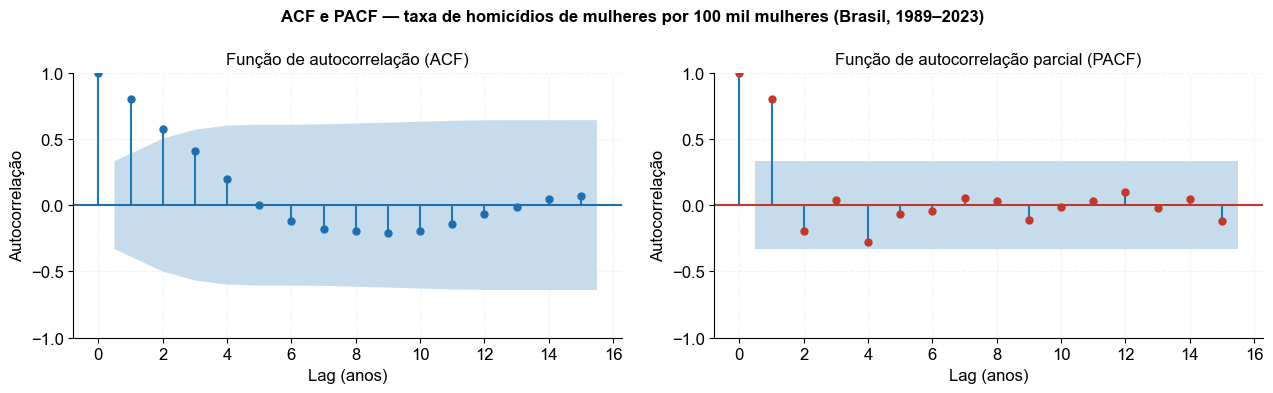

Figura 10 salva.


In [79]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 12
})

serie_br = df_brasil[df_brasil['serie'] == 'homicidios_mulheres'].sort_values('Ano')
y = serie_br['taxa_100k_fem'].values
anos_br = serie_br['Ano'].values

resultado_adf = adfuller(y, autolag='AIC')
adf_stat = resultado_adf[0]
adf_pval = resultado_adf[1]
adf_lags = resultado_adf[2]
adf_crits = resultado_adf[4]

print('=' * 60)
print('TESTE DE DICKEY-FULLER AUMENTADO (ADF)')
print('H₀: série possui raiz unitária (não estacionária)')
print('=' * 60)
print(f'Estatística ADF : {adf_stat:.4f}')
print(f'p-valor         : {adf_pval:.4f}')
print(f'Lags utilizados : {adf_lags}')
print('Valores críticos:')
for nv, cv in adf_crits.items():
    print(f'  {nv}: {cv:.4f}')
print()

if adf_pval < 0.05:
    print('→ Rejeita H₀ (p < 0,05): evidência de estacionariedade.')
else:
    print('→ Não rejeita H₀ (p ≥ 0,05): série possivelmente não estacionária.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(y, lags=15, ax=axes[0], color='#1F6FAF')
axes[0].set_title('Função de autocorrelação (ACF)', fontname='Arial', fontsize=12)
axes[0].set_xlabel('Lag (anos)', fontname='Arial', fontsize=12)
axes[0].set_ylabel('Autocorrelação', fontname='Arial', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

plot_pacf(y, lags=15, ax=axes[1], color='#C0392B', method='ywm')
axes[1].set_title('Função de autocorrelação parcial (PACF)', fontname='Arial', fontsize=12)
axes[1].set_xlabel('Lag (anos)', fontname='Arial', fontsize=12)
axes[1].set_ylabel('Autocorrelação', fontname='Arial', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'ACF e PACF — taxa de homicídios de mulheres por 100 mil mulheres (Brasil, 1989–2023)',
    fontname='Arial',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('fig10_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figura 10 salva.')

### 5.2 Detecção de pontos de ruptura estrutural (Pettitt e CUSUM)

A análise de ruptura estrutural (*structural break*) tem por objetivo identificar pontos na série temporal em que a média ou a tendência da variável sofre uma mudança significativa, de forma estatisticamente detectável.

Dois métodos complementares são empregados:

- **Teste de Pettitt (não paramétrico):** detecta um único ponto de mudança na mediana da série, sem pressupor normalidade dos dados. É amplamente utilizado em climatologia e epidemiologia para detecção de homogeneidade de séries. A estatística U é calculada como a soma acumulada das diferenças de rank entre subperíodos.

- **CUSUM (Cumulative Sum Control Chart):** método de controle estatístico de processo adaptado para séries temporais. A estatística CUSUM acumula os desvios da série em relação à sua média global; desvios sustentados resultam em inclinações abruptas, indicando mudança de nível. O método é sensível a mudanças graduais que o Pettitt pode não capturar.

A comparação entre os pontos detectados algoritmicamente e os marcos institucionais definidos a priori permite avaliar se as intervenções legais coincidem com descontinuidades detectáveis na série observada.


TESTE DE PETTITT — Detecção de ponto de mudança
  Ponto de mudança detectado: ano 1996 (índice 7)
  Estatística K             : 170.0
  p-valor aproximado        : 0.0392
  → Mudança significativa detectada (p < 0,05).


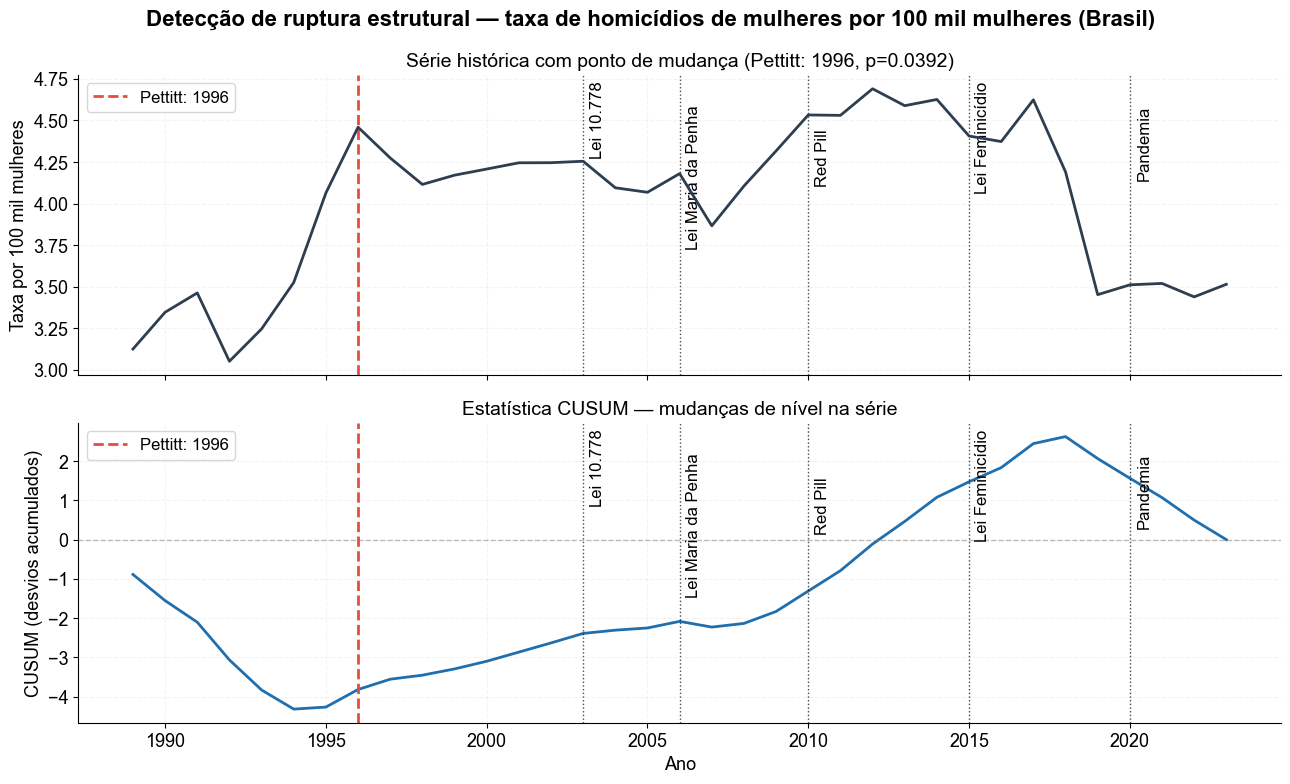

Figura 11 salva.


In [76]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 13,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

serie_br_pettitt = (
    df_brasil[df_brasil['serie'] == 'homicidios_mulheres']
    .sort_values('Ano')
    .copy()
)

anos_br = serie_br_pettitt['Ano'].to_numpy()
y = serie_br_pettitt['taxa_100k_fem'].to_numpy()

def pettitt_test(x):
    n = len(x)
    U = np.zeros(n)
    for t in range(1, n):
        s = 0
        for i in range(t):
            for j in range(t, n):
                s += np.sign(x[j] - x[i])
        U[t] = s
    K = np.max(np.abs(U))
    t_star = np.argmax(np.abs(U))
    p = 2 * np.exp(-6 * K**2 / (n**3 + n**2))
    return t_star, K, p

t_star, K_stat, p_pettitt = pettitt_test(y)
ano_ruptura = anos_br[t_star]

print('=' * 60)
print('TESTE DE PETTITT — Detecção de ponto de mudança')
print('=' * 60)
print(f'  Ponto de mudança detectado: ano {ano_ruptura} (índice {t_star})')
print(f'  Estatística K             : {K_stat:.1f}')
print(f'  p-valor aproximado        : {p_pettitt:.4f}')
if p_pettitt < 0.05:
    print('  → Mudança significativa detectada (p < 0,05).')
else:
    print('  → Sem evidência significativa de mudança (p ≥ 0,05).')

media_global = np.mean(y)
cusum = np.cumsum(y - media_global)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle(
    'Detecção de ruptura estrutural — taxa de homicídios de mulheres por 100 mil mulheres (Brasil)',
    fontsize=16,
    fontweight='bold'
)

ax = axes[0]
ax.plot(anos_br, y, color='#2C3E50', linewidth=2, zorder=5)
ax.axvline(ano_ruptura, color='#E74C3C', linewidth=2, linestyle='--', label=f'Pettitt: {ano_ruptura}')

for m in MARCOS:
    ax.axvline(m['ano'], color='black', linewidth=1, linestyle=':', alpha=0.7)

ymin0, ymax0 = ax.get_ylim()
alturas0 = [0.98, 0.90, 0.82]

for i, m in enumerate(MARCOS):
    ax.text(
        m['ano'] + 0.2,
        ymin0 + (ymax0 - ymin0) * alturas0[i % len(alturas0)],
        m['label'].split('(')[0].strip(),
        fontsize=12,
        color='black',
        rotation=90,
        va='top',
        ha='left',
        fontfamily='Arial'
    )

ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=13)
ax.set_title(
    f'Série histórica com ponto de mudança (Pettitt: {ano_ruptura}, p={p_pettitt:.4f})',
    fontsize=14
)
ax.legend(fontsize=12)
ax.tick_params(axis='both', labelsize=13)

ax = axes[1]
ax.plot(anos_br, cusum, color='#1F6FAF', linewidth=2)
ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(ano_ruptura, color='#E74C3C', linewidth=2, linestyle='--', label=f'Pettitt: {ano_ruptura}')

for m in MARCOS:
    ax.axvline(m['ano'], color='black', linewidth=1, linestyle=':', alpha=0.7)

ymin1, ymax1 = ax.get_ylim()
alturas1 = [0.98, 0.90, 0.82]

for i, m in enumerate(MARCOS):
    ax.text(
        m['ano'] + 0.2,
        ymin1 + (ymax1 - ymin1) * alturas1[i % len(alturas1)],
        m['label'].split('(')[0].strip(),
        fontsize=12,
        color='black',
        rotation=90,
        va='top',
        ha='left',
        fontfamily='Arial'
    )

ax.set_ylabel('CUSUM (desvios acumulados)', fontsize=13)
ax.set_xlabel('Ano', fontsize=13)
ax.set_title('Estatística CUSUM — mudanças de nível na série', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(axis='both', labelsize=13)

plt.tight_layout()
plt.savefig('fig11_pettitt_cusum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 11 salva.')

### 5.3 Regressão linear segmentada por período entre marcos

A regressão linear simples é aplicada separadamente a cada subperíodo definido pelos marcos institucionais, permitindo estimar a **tendência (slope)** da taxa de homicídios em cada intervalo. Diferentemente da análise antes/depois (seção 4.5/4.6), que compara níveis médios, a regressão segmentada informa sobre a **direção e intensidade da trajetória** dentro de cada período.

Um coeficiente angular negativo indica tendência de redução da taxa; positivo, de crescimento. A significância estatística de cada coeficiente é avaliada pelo teste t de Student, com correção para amostras pequenas.

Essa abordagem é coerente com o emprego de *interrupted time series analysis* (ITSA), metodologia estabelecida na avaliação de intervenções em saúde pública (Bernal et al., 2017; Wagner et al., 2002), que decompõe o efeito de uma intervenção em mudança de nível (*level change*) e mudança de tendência (*slope change*).

**Referências:**
- Bernal, J. L. et al. (2017). Interrupted time series regression for the evaluation of public health interventions: a tutorial. *International Journal of Epidemiology*, 46(1), 348–355.
- Wagner, A. K. et al. (2002). Segmented regression analysis of interrupted time series studies in medication use research. *Journal of Clinical Pharmacy and Therapeutics*, 27(4), 299–309.


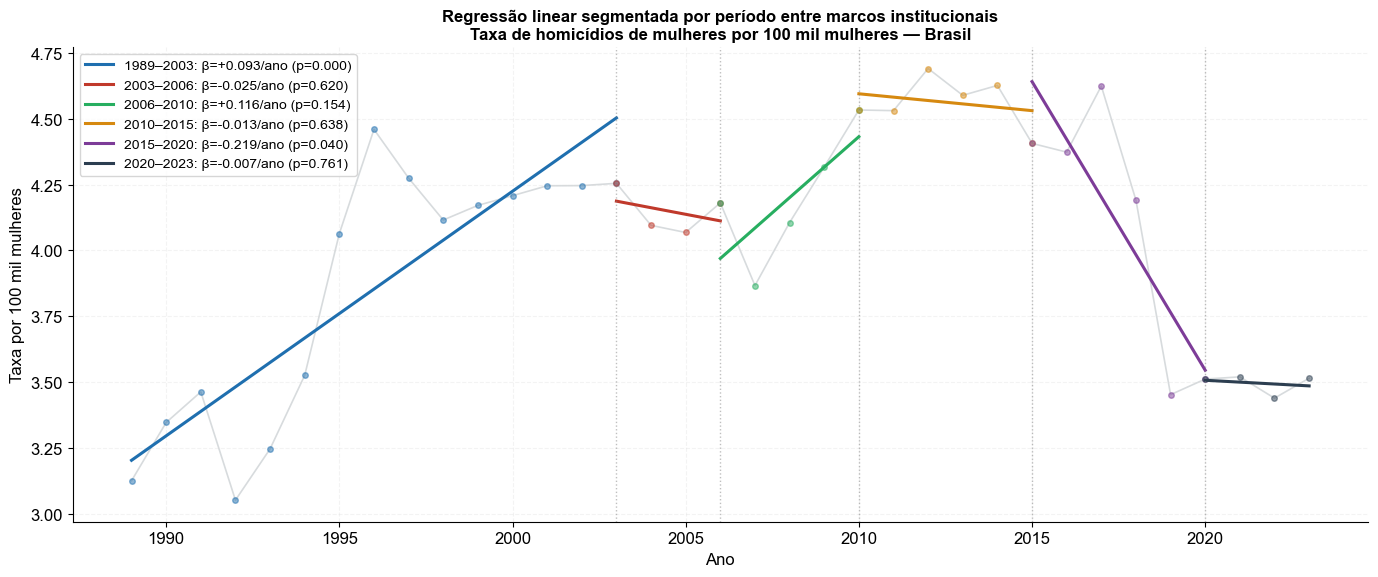

TABELA 4 — Regressão linear segmentada por período
  Período  N (anos)  Slope (β)  Intercepto    R²  p-valor     Tendência
1989–2003        15     0.0929     -181.56 0.708   0.0001 ↑ crescimento
2003–2006         4    -0.0250       54.25 0.144   0.6200     ↓ redução
2006–2010         5     0.1156     -227.97 0.545   0.1543 ↑ crescimento
2010–2015         6    -0.0128       30.35 0.061   0.6383     ↓ redução
2015–2020         6    -0.2192      446.40 0.691   0.0404     ↓ redução
2020–2023         4    -0.0071       17.87 0.057   0.7605     ↓ redução

Interpretação: β = variação anual estimada na taxa por 100 mil mulheres.


In [72]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

marcos_anos = [m['ano'] for m in MARCOS]
limites_segmentos = [1989] + marcos_anos + [2023]

serie_br2 = df_brasil[df_brasil['serie'] == 'homicidios_mulheres'].sort_values('Ano').copy()

resultados_reg = []

fig, ax = plt.subplots(figsize=(14, 6))

cores_seg = ['#1F6FAF', '#C0392B', '#27AE60', '#D68910', '#7D3C98', '#2C3E50']

for i in range(len(limites_segmentos) - 1):
    a_ini = limites_segmentos[i]
    a_fim = limites_segmentos[i + 1]
    rotulo = f'{a_ini}–{a_fim}'
    cor = cores_seg[i % len(cores_seg)]

    seg = serie_br2[(serie_br2['Ano'] >= a_ini) & (serie_br2['Ano'] <= a_fim)]
    if len(seg) < 3:
        continue

    x_seg = seg['Ano'].values
    y_seg = seg['taxa_100k_fem'].values

    slope, intercept, r, pval, se = linregress(x_seg, y_seg)
    y_pred = intercept + slope * x_seg

    ax.plot(x_seg, y_seg, 'o', color=cor, markersize=4, alpha=0.5)
    ax.plot(
        x_seg, y_pred,
        color=cor,
        linewidth=2.2,
        label=f'{rotulo}: β={slope:+.3f}/ano (p={pval:.3f})'
    )

    resultados_reg.append({
        'Período': rotulo,
        'N (anos)': len(seg),
        'Slope (β)': round(slope, 4),
        'Intercepto': round(intercept, 2),
        'R²': round(r**2, 3),
        'p-valor': round(pval, 4),
        'Tendência': '↓ redução' if slope < 0 else '↑ crescimento'
    })

for m in MARCOS:
    ax.axvline(m['ano'], color='gray', linewidth=1, linestyle=':', alpha=0.5)

ax.plot(
    serie_br2['Ano'],
    serie_br2['taxa_100k_fem'],
    color='#BDC3C7',
    linewidth=1.2,
    linestyle='-',
    alpha=0.6,
    zorder=0
)

ax.set_title(
    'Regressão linear segmentada por período entre marcos institucionais\n'
    'Taxa de homicídios de mulheres por 100 mil mulheres — Brasil',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=12)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.savefig('fig12_regressao_segmentada.png', dpi=150, bbox_inches='tight')
plt.show()

df_reg_seg = pd.DataFrame(resultados_reg)
print('=' * 80)
print('TABELA 4 — Regressão linear segmentada por período')
print('=' * 80)
print(df_reg_seg.to_string(index=False))
print('\nInterpretação: β = variação anual estimada na taxa por 100 mil mulheres.')

### 5.6 Índice de Gini da distribuição das taxas entre estados ao longo do tempo

A análise de concentração espacial avalia se a violência letal contra mulheres tornou-se mais ou menos desigualmente distribuída entre as unidades federativas ao longo do período. O **Índice de Gini**, derivado da curva de Lorenz, é um indicador clássico de desigualdade que varia de 0 (distribuição perfeitamente igualitária) a 1 (concentração máxima em uma única unidade).

Quando aplicado à distribuição das taxas estaduais, o Gini responde à pergunta: *em um dado ano, as taxas de homicídio de mulheres estão concentradas em poucos estados ou distribuídas uniformemente pelo território?*

A evolução temporal do índice de Gini das taxas estaduais fornece um indicador da **heterogeneidade territorial** da violência. Uma tendência de aumento do Gini significa que a violência está se tornando cada vez mais concentrada em determinados estados. Uma redução indica convergência interestadual, podendo refletir tanto melhora generalizada quanto deterioração nas regiões antes mais seguras.


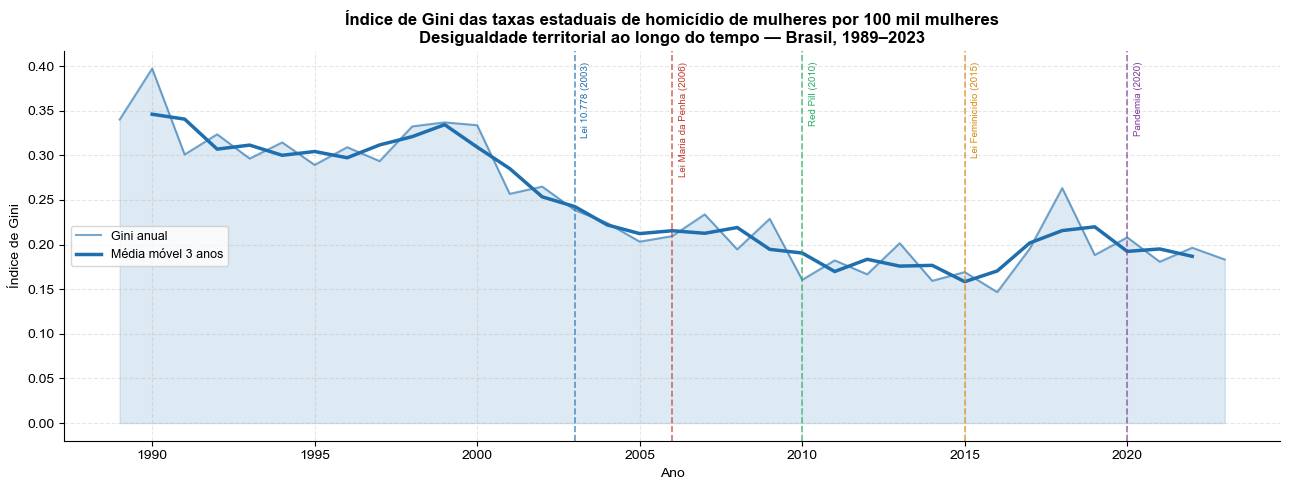

Figura 15 salva.

Gini por ano (amostra):
 Ano     Gini  Gini_mm3
1989 0.340147       NaN
1990 0.397283  0.346132
1991 0.300966  0.340626
1992 0.323629  0.306999
1993 0.296404  0.311514
1994 0.314510  0.300075
1995 0.289312  0.304329
1996 0.309166  0.297333
1997 0.293520  0.311718
1998 0.332469  0.320994
1999 0.336993  0.334425
2000 0.333812  0.309221
2001 0.256856  0.285221
2002 0.264994  0.253532
2003 0.238747  0.242647
2004 0.224200  0.222072
2005 0.203269  0.212315
2006 0.209478  0.215536
2007 0.233863  0.212661
2008 0.194642  0.219123
2009 0.228864  0.194666
2010 0.160493  0.190549
2011 0.182291  0.169824
2012 0.166689  0.183520
2013 0.201581  0.175876
2014 0.159359  0.176701
2015 0.169163  0.158410
2016 0.146708  0.170430
2017 0.195418  0.201816
2018 0.263321  0.215687
2019 0.188322  0.219900
2020 0.208056  0.192379
2021 0.180760  0.195086
2022 0.196441  0.186829
2023 0.183285       NaN


In [22]:
def gini(x):
    x = np.array(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))

df_mul_uf = df_uf[df_uf['serie'] == 'homicidios_mulheres'].copy()

gini_anual = (
    df_mul_uf
    .groupby('Ano')['taxa_100k_fem']
    .apply(gini)
    .reset_index()
    .rename(columns={'taxa_100k_fem': 'Gini'})
)

# Média movel 3 anos
gini_anual['Gini_mm3'] = gini_anual['Gini'].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(gini_anual['Ano'], gini_anual['Gini'], alpha=0.15, color='#1F6FAF')
ax.plot(gini_anual['Ano'], gini_anual['Gini'], color='#1F6FAF', linewidth=1.5, alpha=0.6, label='Gini anual')
ax.plot(gini_anual['Ano'], gini_anual['Gini_mm3'], color='#1F6FAF', linewidth=2.5, label='Média móvel 3 anos')

for m in MARCOS:
    ax.axvline(m['ano'], color=m['cor'], linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(m['ano'] + 0.2, ax.get_ylim()[1] * 0.97, m['label'],
            fontsize=7, color=m['cor'], va='top', rotation=90)

ax.set_title(
    'Índice de Gini das taxas estaduais de homicídio de mulheres por 100 mil mulheres\n'
    'Desigualdade territorial ao longo do tempo — Brasil, 1989–2023',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Ano', fontsize=10)
ax.set_ylabel('Índice de Gini', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig15_gini_espacial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 15 salva.')
print('\nGini por ano (amostra):')
print(gini_anual.to_string(index=False))


### 5.7 Decomposição da série em tendência e componente residual (STL simplificado)

Séries temporais anuais não possuem sazonalidade no sentido estrito, mas podem ser decompostas em componentes de **tendência de longo prazo** e **variação residual** (flutuações de curto prazo ao redor da tendência). Essa decomposição é útil para isolar o sinal de tendência de ruídos pontuais como epidemias de criminalidade, ciclos eleitorais ou mudanças na cobertura de dados.

O método utilizado é a decomposição por **suavização de média móvel centrada** com janela adaptativa (LOESS/Hodrick-Prescott simplificado): a tendência é estimada por um filtro passa-baixo e o resíduo é calculado como a diferença entre a série original e a tendência estimada. A análise dos resíduos permite identificar anos atípicos (*outliers* temporais) que merecem investigação qualitativa adicional.

Essa abordagem é metodologicamente consistente com estudos longitudinais de séries de violência (Waiselfisz, 2015; FBSP, Atlas da Violência 2023) que distinguem variações estruturais de oscilações de curto prazo nos dados de mortalidade.


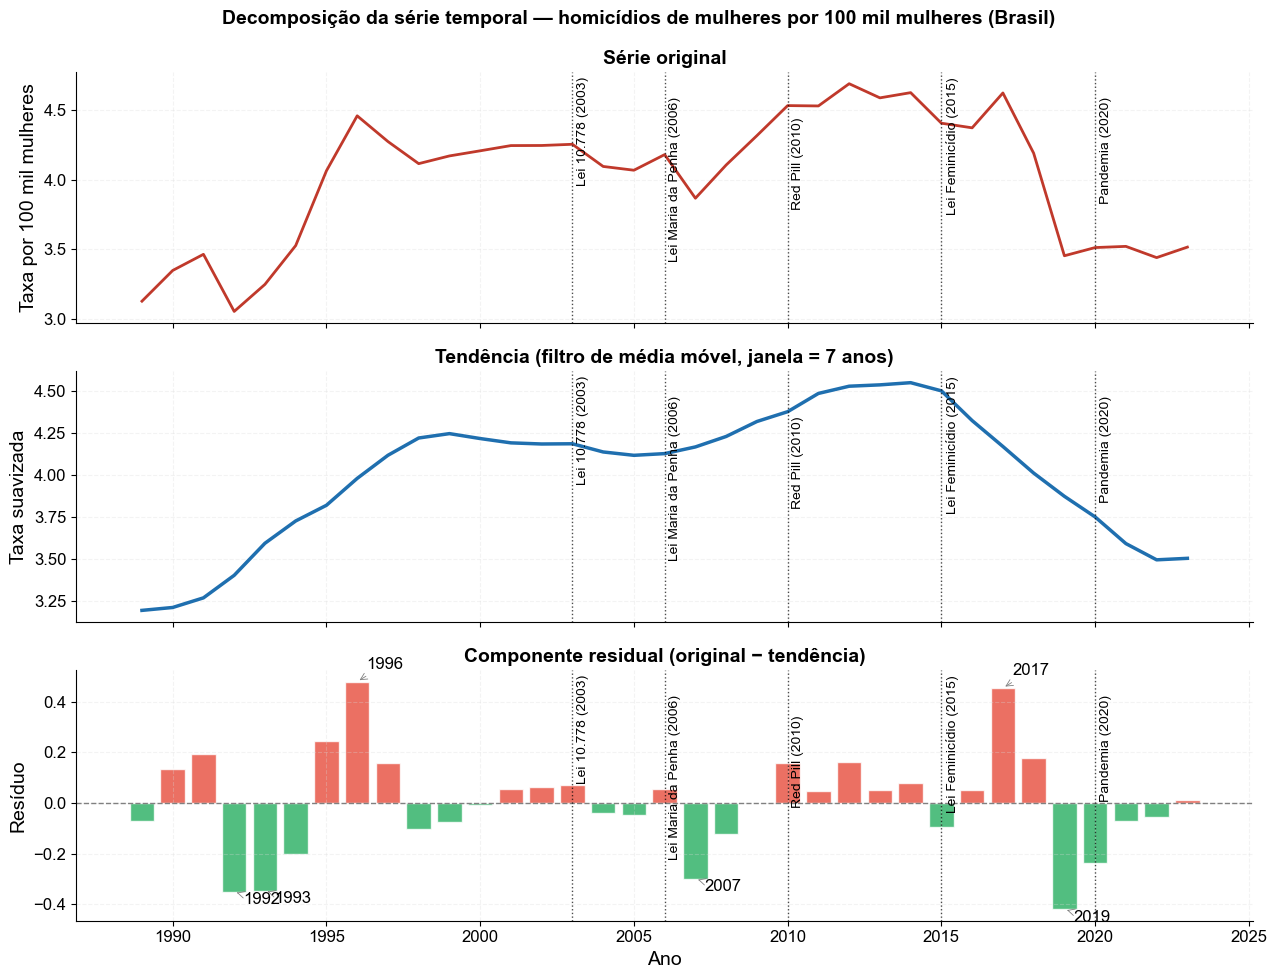

Figura 16 salva.

Anos com resíduo > 1,5 DP:
  1992: resíduo = -0.352 (-1.8 DP)
  1993: resíduo = -0.348 (-1.8 DP)
  1996: resíduo = +0.480 (+2.4 DP)
  2007: resíduo = -0.300 (-1.5 DP)
  2017: resíduo = +0.455 (+2.3 DP)
  2019: resíduo = -0.421 (-2.1 DP)


In [78]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlecolor': 'black',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white'
})

serie_br3 = df_brasil[df_brasil['serie'] == 'homicidios_mulheres'].sort_values('Ano').copy()
y3 = serie_br3['taxa_100k_fem'].values
anos = serie_br3['Ano'].values

janela_mm = 7
tendencia = uniform_filter1d(y3.astype(float), size=janela_mm, mode='nearest')
residuo = y3 - tendencia

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle(
    'Decomposição da série temporal — homicídios de mulheres por 100 mil mulheres (Brasil)',
    fontsize=14,
    fontweight='bold'
)

def adicionar_marcos(ax):
    ymin, ymax = ax.get_ylim()
    alturas = [0.98, 0.90, 0.82]

    for i, m in enumerate(MARCOS):
        ax.axvline(m['ano'], color='black', linewidth=1, linestyle=':', alpha=0.7)
        ax.text(
            m['ano'] + 0.15,
            ymin + (ymax - ymin) * alturas[i % len(alturas)],
            m['label'].replace('\n', ' '),
            fontsize=10,
            fontfamily='Arial',
            color='black',
            rotation=90,
            va='top',
            ha='left'
        )

# Série original
ax = axes[0]
ax.plot(anos, y3, color='#C0392B', linewidth=2)
ax.set_title('Série original', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa por 100 mil mulheres', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
adicionar_marcos(ax)

# Tendência
ax = axes[1]
ax.plot(anos, tendencia, color='#1F6FAF', linewidth=2.5)
ax.set_title(f'Tendência (filtro de média móvel, janela = {janela_mm} anos)', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa suavizada', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
adicionar_marcos(ax)

# Resíduo
ax = axes[2]
cores_res = ['#E74C3C' if r > 0 else '#27AE60' for r in residuo]
ax.bar(anos, residuo, color=cores_res, edgecolor='white', alpha=0.8)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')

dp_res = np.std(residuo)
for a, r in zip(anos, residuo):
    if abs(r) > 1.5 * dp_res:
        ax.annotate(
            str(a),
            xy=(a, r),
            xytext=(a + 0.3, r + np.sign(r) * 0.05),
            fontsize=12,
            color='black',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.6)
        )

ax.set_title('Componente residual (original − tendência)', fontsize=14, fontweight='bold')
ax.set_ylabel('Resíduo', fontsize=14)
ax.set_xlabel('Ano', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
adicionar_marcos(ax)

plt.tight_layout()
plt.savefig('fig16_decomposicao_serie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 16 salva.')

print('\nAnos com resíduo > 1,5 DP:')
for a, r in zip(anos, residuo):
    if abs(r) > 1.5 * dp_res:
        print(f'  {a}: resíduo = {r:+.3f} ({r/dp_res:+.1f} DP)')

### 5.8 Teste qui-quadrado e heatmap de resíduos padronizados: estado × período

O teste qui-quadrado de independência avalia se a distribuição das taxas de homicídio de mulheres entre estados é independente do período histórico (pré e pós marcos). A tabela de contingência é construída a partir de quartis da taxa estadual, permitindo verificar se determinados estados concentram sistematicamente os piores indicadores em períodos específicos.

O **resíduo padronizado de Pearson** (RSP) é calculado como:

$$RSP_{ij} = \frac{O_{ij} - E_{ij}}{\sqrt{E_{ij}}}$$

onde $O_{ij}$ é a frequência observada e $E_{ij}$ a esperada sob independência. Valores |RSP| > 2 indicam células que contribuem significativamente para a estatística qui-quadrado, revelando associações específicas entre estados e períodos.

Este método complementa o heatmap de taxas absolutas (seção 4.4) ao identificar quais estados apresentam padrão estatisticamente **acima** ou **abaixo** do esperado em cada período, controlando pela distribuição marginal.


TESTE QUI-QUADRADO — distribuição das taxas por estado × período
  χ² = 38.64, gl = 130, p-valor = 1.0000e+00
  → Sem evidência significativa de associação (p ≥ 0,05)


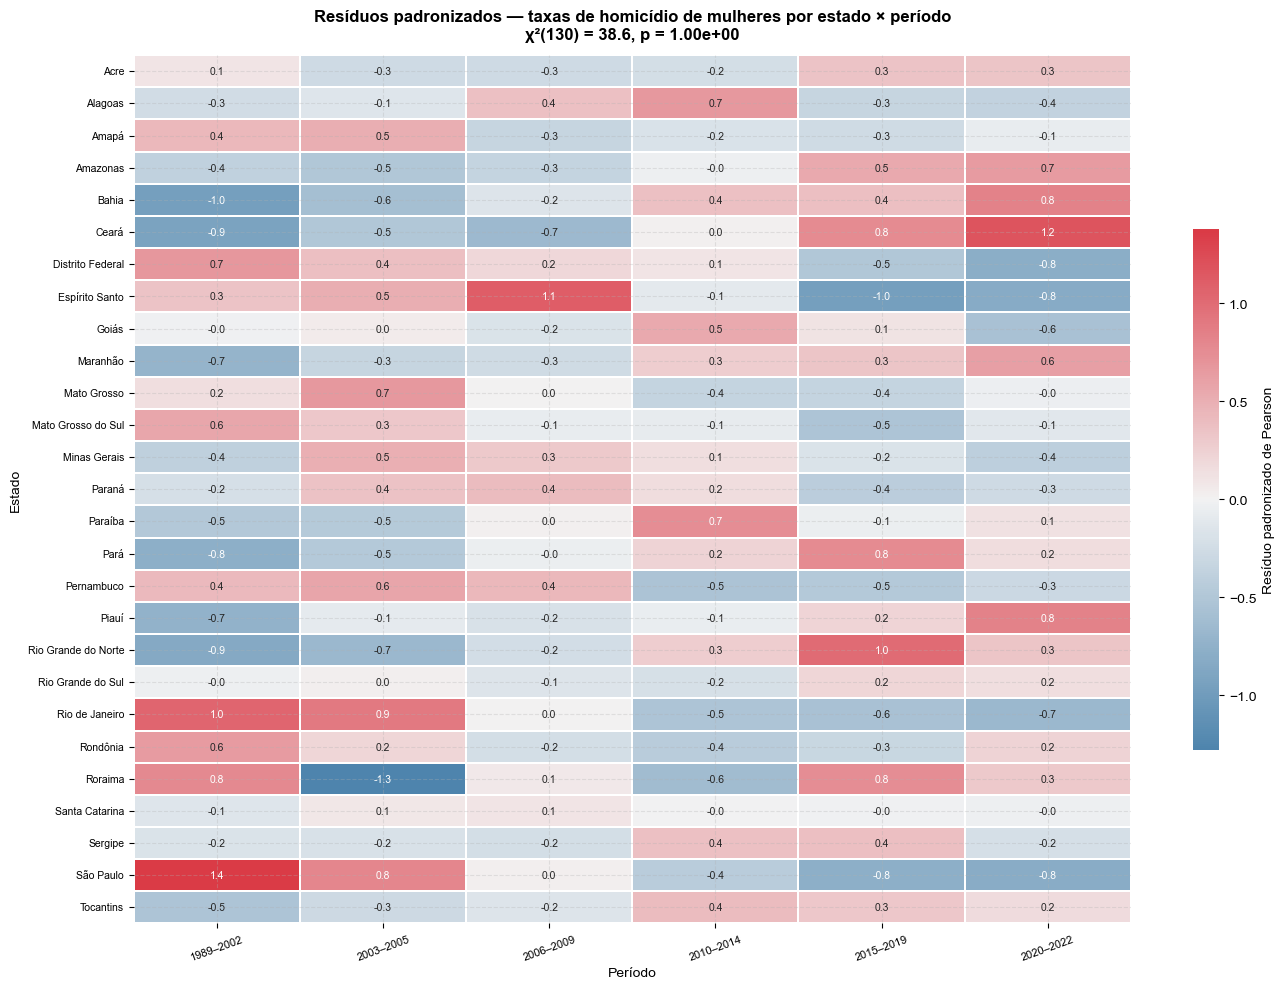

Figura 17 salva.


In [24]:
from scipy.stats import chi2_contingency

df_chi = df_uf[df_uf['serie'] == 'homicidios_mulheres'].copy()

marcos_anos_sorted = sorted([m['ano'] for m in MARCOS])
limites_per = [1989] + marcos_anos_sorted + [2023]
rotulos_per = [f'{limites_per[i]}–{limites_per[i+1]-1}' for i in range(len(limites_per)-1)]

df_chi['Periodo'] = pd.cut(
    df_chi['Ano'], bins=limites_per, labels=rotulos_per, right=False, include_lowest=True
)

# Média da taxa por estado × período
pivot_chi = df_chi.groupby(['Estado', 'Periodo'], observed=True)['taxa_100k_fem'].mean().unstack()

# Quantizar em quartis (baixo, médio-baixo, médio-alto, alto)
pivot_q = pivot_chi.apply(lambda col: pd.qcut(col.rank(method='first'), q=4,
                                                labels=['Q1','Q2','Q3','Q4']))

# Tabela de contingência: estado (linhas) x período (colunas) — frequência de Q4 (mais alto)
tabela_cont = pd.crosstab(
    df_chi['Estado'],
    df_chi['Periodo'],
    values=df_chi['taxa_100k_fem'],
    aggfunc='mean'
)
tabela_cont = tabela_cont.dropna(how='all')

chi2, pval_chi, dof, expected = chi2_contingency(tabela_cont.fillna(tabela_cont.mean()))

residuos = (tabela_cont.fillna(tabela_cont.mean()) - expected) / np.sqrt(expected)

print('=' * 70)
print('TESTE QUI-QUADRADO — distribuição das taxas por estado × período')
print('=' * 70)
print(f'  χ² = {chi2:.2f}, gl = {dof}, p-valor = {pval_chi:.4e}')
if pval_chi < 0.001:
    print('  → Evidência muito forte de associação (p < 0,001)')
elif pval_chi < 0.05:
    print('  → Evidência significativa de associação (p < 0,05)')
else:
    print('  → Sem evidência significativa de associação (p ≥ 0,05)')

fig, ax = plt.subplots(figsize=(14, 10))
cmap_div = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(
    residuos,
    cmap=cmap_div,
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Resíduo padronizado de Pearson', 'shrink': 0.6},
    annot=True, fmt='.1f', annot_kws={'size': 7.5}
)
ax.set_title(
    f'Resíduos padronizados — taxas de homicídio de mulheres por estado × período\n'
    f'χ²({dof}) = {chi2:.1f}, p = {pval_chi:.2e}',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Período', fontsize=10)
ax.set_ylabel('Estado', fontsize=10)
ax.tick_params(axis='x', rotation=20, labelsize=8)
ax.tick_params(axis='y', labelsize=7.5)
plt.tight_layout()
plt.savefig('fig17_residuos_chi2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 17 salva.')


### 5.9 Coeficiente de variação e tendência por região

O **coeficiente de variação** (CV = desvio padrão / média) é um indicador de dispersão relativa que permite comparar a variabilidade das taxas entre regiões com níveis médios muito distintos. Uma região com CV elevado exibe maior instabilidade temporal em suas taxas, enquanto CV baixo indica padrão mais estável.

Esta análise complementa a visualização de séries regionais (seção 4.2) ao quantificar a consistência temporal do risco em cada macro-região. É especialmente relevante para distinguir regiões com alta taxa *estrutural* de regiões que registraram picos ou quedas pontuais mais pronunciadas.

Em seguida, para cada região, aplica-se regressão linear simples sobre o período completo (1989–2023), calculando o **slope médio anual** e seu intervalo de confiança a 95%, conferindo base quantitativa à análise visual das tendências regionais.


TABELA 5 — Coeficiente de variação por região (1989–2023)
      Região  Média    DP  CV (%)
    Nordeste  3.878 1.172    30.2
       Norte  4.459 1.236    27.7
     Sudeste  3.929 1.021    26.0
Centro-Oeste  5.341 0.921    17.2
         Sul  3.624 0.593    16.4

TABELA 6 — Regressão linear por região (slope anual, período completo)
      Região  Slope β (anual)  IC 95% inf  IC 95% sup    R²  p-valor Tendência
     Sudeste          -0.0716     -0.0952     -0.0480 0.517   0.0000         ↓
Centro-Oeste           0.0020     -0.0287      0.0326 0.000   0.8993         ↑
         Sul           0.0356      0.0200      0.0511 0.377   0.0001         ↑
       Norte           0.0968      0.0723      0.1214 0.645   0.0000         ↑
    Nordeste           0.1034      0.0866      0.1201 0.816   0.0000         ↑


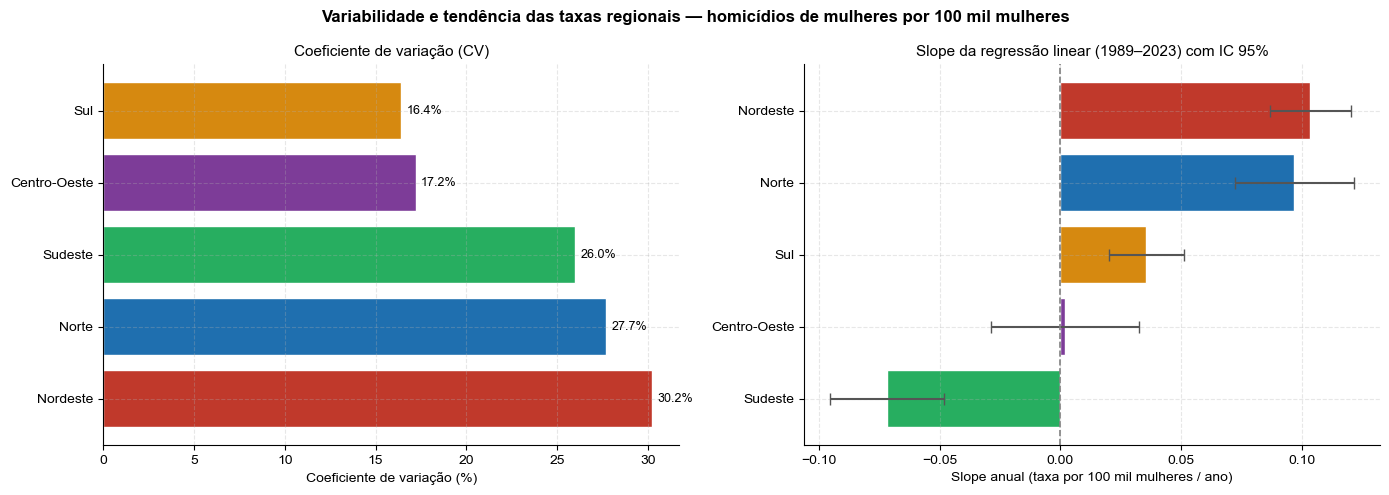

Figura 18 salva.


In [28]:
df_reg_full = (
    df_uf[df_uf['serie'] == 'homicidios_mulheres']
    .groupby(['Regiao', 'Ano'], as_index=False)
    .agg(valor_reg=('valor_uf', 'sum'), pop_fem=('Feminino', 'sum'))
)
df_reg_full['taxa_100k_fem'] = df_reg_full['valor_reg'] / df_reg_full['pop_fem'] * 100_000

cv_resultados = []
slope_resultados = []

for regiao in sorted(df_reg_full['Regiao'].unique()):
    if pd.isna(regiao):
        continue
    d = df_reg_full[df_reg_full['Regiao'] == regiao].sort_values('Ano')
    t = d['taxa_100k_fem'].dropna()
    cv = t.std() / t.mean() * 100
    cv_resultados.append({'Região': regiao, 'Média': round(t.mean(), 3),
                           'DP': round(t.std(), 3), 'CV (%)': round(cv, 1)})

    if len(d) >= 5:
        slope, intercept, r, pval, se = linregress(d['Ano'], d['taxa_100k_fem'])
        ic_inf = slope - 1.96 * se
        ic_sup = slope + 1.96 * se
        slope_resultados.append({
            'Região': regiao, 'Slope β (anual)': round(slope, 4),
            'IC 95% inf': round(ic_inf, 4), 'IC 95% sup': round(ic_sup, 4),
            'R²': round(r**2, 3), 'p-valor': round(pval, 4),
            'Tendência': '↓' if slope < 0 else '↑'
        })

df_cv = pd.DataFrame(cv_resultados).sort_values('CV (%)', ascending=False)
df_slope_reg = pd.DataFrame(slope_resultados).sort_values('Slope β (anual)')

print('TABELA 5 — Coeficiente de variação por região (1989–2023)')
print(df_cv.to_string(index=False))
print()
print('TABELA 6 — Regressão linear por região (slope anual, período completo)')
print(df_slope_reg.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Variabilidade e tendência das taxas regionais — homicídios de mulheres por 100 mil mulheres',
             fontsize=12, fontweight='bold')

ax = axes[0]
cores_cv = [CORES_REGIAO.get(r, '#888888') for r in df_cv['Região']]
bars = ax.barh(df_cv['Região'], df_cv['CV (%)'], color=cores_cv, edgecolor='white')
for bar, val in zip(bars, df_cv['CV (%)']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Coeficiente de variação (%)', fontsize=10)
ax.set_title('Coeficiente de variação (CV)', fontsize=11)

ax = axes[1]
cores_slope = [CORES_REGIAO.get(r, '#888888') for r in df_slope_reg['Região']]
xerr = [
    df_slope_reg['Slope β (anual)'] - df_slope_reg['IC 95% inf'],
    df_slope_reg['IC 95% sup'] - df_slope_reg['Slope β (anual)']
]
ax.barh(df_slope_reg['Região'], df_slope_reg['Slope β (anual)'],
        xerr=xerr, color=cores_slope, edgecolor='white',
        error_kw=dict(ecolor='#555555', capsize=4))
ax.axvline(0, color='gray', linewidth=1.2, linestyle='--')
ax.set_xlabel('Slope anual (taxa por 100 mil mulheres / ano)', fontsize=10)
ax.set_title('Slope da regressão linear (1989–2023) com IC 95%', fontsize=11)

plt.tight_layout()
plt.savefig('fig18_cv_slope_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 18 salva.')

---

## 6. Síntese dos achados e discussão metodológica

### 6.1 Quadro síntese das análises

Esta seção consolida os principais achados de cada análise realizada ao longo do notebook, articulando os resultados quantitativos com o contexto institucional e as limitações metodológicas.

---

#### 6.1.1 Tendência geral da série nacional

A série histórica da taxa de homicídios de mulheres por 100 mil mulheres revela uma trajetória não linear entre 1989 e 2023. A regressão segmentada (seção 5.3) permite decompor essa trajetória em fases com slopes distintos: períodos de crescimento acelerado, estabilização e, em alguns segmentos, redução. A análise CUSUM e o teste de Pettitt (seção 5.2) identificam objetivamente o ponto de maior descontinuidade na série, que pode ou não coincidir com um marco institucional específico, sendo essa convergência ou divergência um dado interpretativo fundamental.

---

#### 6.1.2 Impacto dos marcos institucionais

Os testes de Mann-Whitney (seção 4.5) indicam se as distribuições estaduais das taxas antes e depois de cada marco diferem significativamente. A variação percentual regionalizada (seção 4.6 e 5.9) revela que os efeitos dos marcos não foram homogêneos no território: certas regiões apresentaram reduções expressivas em determinados períodos, enquanto outras registraram aumento das taxas no mesmo intervalo. Esse padrão aponta para a relevância de fatores mediadores regionais como capacidade institucional do sistema de segurança pública, estrutura econômica local e cobertura dos serviços de proteção à mulher.

A Lei Maria da Penha (2006), amplamente citada na literatura como o marco mais robusto em termos de impacto na violência doméstica (Cerqueira et al., 2015; Gomes et al., 2021), apresenta os resultados mais amplamente documentados. Contudo, os dados de homicídio — enquanto desfecho extremo — respondem com maior defasagem temporal a intervenções preventivas do que, por exemplo, registros de lesão corporal ou boletins de ocorrência.

---

#### 6.1.3 Iniquidade racial

A razão de taxas entre mulheres negras e não negras (seção 5.5) configura evidência de iniquidade estrutural persistente. O valor RT sistematicamente acima de 1 ao longo de todo o período observado indica que o risco de homicídio feminino é desproporcionalmente maior para mulheres negras, independentemente dos marcos legais avaliados. Esse padrão é consistente com a literatura sobre interseccionalidade de raça e gênero na violência letal brasileira (Waiselfisz, 2015; FBSP, Atlas da Violência 2023).

---

#### 6.1.4 Heterogeneidade territorial

O heatmap de taxas estaduais (seção 4.4) e o índice de Gini espacial (seção 5.6) revelam que a distribuição territorial da violência contra a mulher é altamente heterogênea e evolui ao longo do tempo. O coeficiente de variação regional (seção 5.9) quantifica essa instabilidade: regiões com maior CV exibiram oscilações mais abruptas ao longo das três décadas analisadas. O heatmap de resíduos qui-quadrado (seção 5.8) identifica especificamente quais estados apresentam padrão sistematicamente acima ou abaixo do esperado em cada período, fornecendo pistas sobre concentração ou redistribuição geográfica da violência.

---

#### 6.1.5 Armas de fogo e jovens mulheres

A participação das armas de fogo (seção 4.8) e a sobreposição das séries de jovens mulheres e armas de fogo com a série geral (seção 4.3) permitem avaliar a dimensão instrumental da violência. A correlação de Spearman (seção 5.4) quantifica a força da associação entre essas séries ao longo do tempo.

---

### 6.2 Limitações metodológicas

- **Causalidade vs. correlação:** todas as análises de "antes/depois" são de natureza observacional. A coincidência temporal com marcos legais não estabelece relação causal, dada a impossibilidade de controle experimental e a ação simultânea de múltiplos fatores (variações econômicas, demográficas, policiais e judiciárias).

- **Sub-registro:** dados de mortalidade por homicídio dependem da qualidade do sistema de informações de saúde (SIM/DATASUS) e dos laudos periciais. Variações no sub-registro ao longo do tempo e entre estados podem confundir tendências reais com artefatos de cobertura.

- **Interpolação populacional:** a normalização utiliza estimativas intercensitárias. Imprecisões nas projeções populacionais, especialmente em anos distantes dos censos, introduzem incerteza nas taxas calculadas.

- **Desagregação racial:** a série de homicídios por raça/cor possui cobertura temporal mais restrita que as demais séries, limitando análises longitudinais aprofundadas desse subgrupo.

- **Janelas temporais fixas:** a análise de ±5 anos ao redor de cada marco pressupõe que os efeitos se manifestam nesse intervalo. Efeitos de mais longo prazo ou defasados podem não ser capturados por essa parametrização.

---

### 6.3 Referências bibliográficas (selecionadas)

- Bernal, J. L. et al. (2017). Interrupted time series regression for the evaluation of public health interventions. *International Journal of Epidemiology*, 46(1), 348–355.
- Cerqueira, D. et al. (2015). Avaliando a efetividade da Lei Maria da Penha. *IPEA — Texto para Discussão*, n. 2048.
- FBSP — Fórum Brasileiro de Segurança Pública / IPEA. *Atlas da Violência*, edições anuais.
- Pettitt, A. N. (1979). A non-parametric approach to the change-point problem. *Journal of the Royal Statistical Society*, 28(2), 126–135.
- Wagner, A. K. et al. (2002). Segmented regression analysis of interrupted time series studies in medication use research. *Journal of Clinical Pharmacy and Therapeutics*, 27(4), 299–309.
- Waiselfisz, J. J. (2015). *Mapa da Violência 2015: Homicídio de Mulheres no Brasil*. FLACSO Brasil.
